# M66 Genetic Algorithm Service Optimization

This notebook rebuilds and validates the M66 reference simulation conditions, then applies the same Genetic Algorithm (GA) service-allocation method to Baseline, High-Demand, Reduced-Service, and Combined conditions.

The optimizer redistributes each scenario's fixed Morning and Evening trip budget across the five study hours. Candidate buses are evenly spaced within each hour, downstream arrivals use hour-specific median GTFS travel offsets, and candidate starting occupancy and alighting assignments are recalculated from the same scenario inputs used by the simulation.

The GA search uses the first five matched replications, optimizer seeds 101, 202, and 303, and a budget of 100 unique service plans per optimizer run. Final plan selection is based on the full matched validation-replication set and requires the selected plan's mean final backlog to be no worse than the matching reference service.

Reduced-Service and Combined use fixed period budgets of 38 Morning trips and 39 Evening trips with hourly feasibility bounds of 4 to 12 trips. Combined uses the High-Demand passenger streams together with the Reduced-Service service condition.


Run this notebook from the first cell with a fresh kernel. Follow the notebook order in the root README, use the code folder as the working directory, and save the notebook with its outputs.


### Notebook Role

**Purpose:** Apply the selected Genetic Algorithm consistently to Baseline, High-Demand, Reduced-Service, and Combined conditions and validate the selected plans against their matching references.

**Run order:** 4 of 4

**Main outputs:** GA run results, selected plans, safeguards, precision checks, stop-level results, paired 95% confidence intervals, and the GA output manifest.

**Technical reference:** `../docs/TECHNICAL_DOCUMENTATION.md`


In [1]:
from pathlib import Path
import heapq
import ast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t

### Technical Reference

Detailed data, simulation, optimization, validation, and methodological references are documented in `../docs/TECHNICAL_DOCUMENTATION.md`.


## 1. Setup and Configuration

In [2]:
#locate the modesim_project directory from common notebook launch locations.
working_dir = Path.cwd()

project_candidates = [
    working_dir,
    working_dir.parent,
    working_dir / "MODESIM_Project",
]

project_dir = next(
    (
        path
        for path in project_candidates
        if (path / "code").exists() and (path / "data").exists()
    ),
    None,
)

if project_dir is None:
    raise FileNotFoundError(
        "Could not locate MODESIM_Project. "
        "Run the notebook from the repository root or MODESIM_Project/code."
    )

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
gtfs_dir = raw_dir / "gtfs_m"

figures_dir = project_dir / "output" / "figures"
tables_dir = project_dir / "output" / "tables"

clean_file = processed_dir / "MTA_M66_Selected_Stops_2025_CLEAN.csv"
raw_file = raw_dir / "MTA_M66_Eastbound_2025_RAW.csv"

figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

required_inputs = [
    clean_file,
    raw_file,
    gtfs_dir / "trips.txt",
    gtfs_dir / "stop_times.txt",
]

missing_inputs = [path for path in required_inputs if not path.exists()]

if missing_inputs:
    missing_list = "\n".join(f"- {path}" for path in missing_inputs)
    raise FileNotFoundError(
        f"Required simulation inputs are missing:\n{missing_list}"
    )

print("Project directory located successfully.")
print("Required simulation inputs found.")
#make local modules work from the repository root or the notebook folder
import sys
code_dir = str(project_dir / "code")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)
from m66_support import (
    PASSENGER_COLUMNS, allocate_initial_occupancy, finite_replications,
    paired_difference, validate_demand
)


Project directory located successfully.
Required simulation inputs found.


In [3]:
#core simulation configuration
bus_capacity = 60

morning_hours = [6, 7, 8, 9, 10]
evening_hours = [15, 16, 17, 18, 19]
study_hours = morning_hours + evening_hours

selected_stops = [6, 7, 8, 9, 10]

master_seed = 2026

#scenario parameters
demand_growth_factor = 1.40
trips_removed_per_hour = 1

#replication and precision parameters
precision_start_replications = 30
precision_increment = 10
precision_max_replications = 50
precision_confidence_level = 0.95


## 2. Load Passenger Demand

In [4]:
#load the cleaned m66 selected-stop dataset used as the passenger-demand input
#for all simulation scenarios.
df = pd.read_csv(clean_file)

#convert the date and hour fields into consistent datetime/hour values so the
#records can be checked against the defined study periods.
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Hour"]).dt.hour

#collect the study hours and stop sequences that are actually present in the
#processed dataset.
actual_hours = sorted(df["Hour"].unique().tolist())
actual_stops = sorted(df["Stop Sequence"].unique().tolist())

#fail early if the loaded dataset does not contain exactly the study hours
#expected by the simulation configuration.
if actual_hours != study_hours:
    raise ValueError(
        f"Unexpected study hours. Expected {study_hours}, found {actual_hours}."
    )

#fail early if the loaded dataset contains a different set of modeled stops.
#this prevents the simulation from silently running with the wrong input data.
if actual_stops != selected_stops:
    raise ValueError(
        f"Unexpected selected stops. Expected {selected_stops}, "
        f"found {actual_stops}."
    )

#display a compact input summary so a reviewer can confirm that the intended
#processed dataset was loaded before the simulation continues.
print(f"Cleaned rows: {len(df):,}")
print(f"Study hours: {actual_hours}")
print(f"Selected stops: {actual_stops}")

Cleaned rows: 12,814
Study hours: [6, 7, 8, 9, 10, 15, 16, 17, 18, 19]
Selected stops: [6, 7, 8, 9, 10]


In [5]:
#reference: pandas dataframe.groupby()
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html
#
#average mean boardings/alightings by stop-hour, and the baseline
#whole-number passenger count used by the simulation. identical rounding
#rule as the baseline notebook: max(0, floor(p + 0.5)).

demand_table = (
    df.groupby(["Stop Sequence", "Stop Name", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
    .sort_values(["Stop Sequence", "Hour"])
    .reset_index(drop=True)
)

baseline_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

baseline_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(baseline_demand["Boardings"] + 0.5)
).astype(int)

print("Baseline passenger total per replication:", baseline_demand["Passenger Count"].sum())
baseline_demand.head(10)


Baseline passenger total per replication: 776


,Stop Sequence,Stop Name,Hour,Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,8
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,25
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,40
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,24
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,19
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,34
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,28
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,31
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,22
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,11


## 3. Build High-Demand Passenger Demand

The High-Demand scenario increases boarding demand by 40% at each modeled stop-hour while keeping the same stops, study hours, and Baseline service conditions.

For a Baseline stop-hour boarding value \(p\), the High-Demand passenger count is calculated as:

\[
p_{HD} = \max(0,\lfloor 1.40p + 0.5 \rfloor)
\]

The `+0.5` before applying the floor operation implements the same half-up whole-passenger rounding rule used for the Baseline demand inputs. Because rounding is performed separately for every stop-hour cell, the realized total increase may differ slightly from exactly 40%.

For matched scenario comparisons, the original Baseline passengers are preserved. Only the additional passengers required to reach the High-Demand count are generated separately using a deterministic random sub-stream. This allows the Baseline portion of the passenger stream to remain unchanged between Baseline and High-Demand replications.

In [6]:
#build the high-demand stop-hour table from the same demand inputs used
#for the baseline scenario.
high_demand_demand = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Boardings"]
].copy()

#increase boarding demand by the configured high-demand multiplier.
high_demand_demand["Scaled Boardings"] = (
    high_demand_demand["Boardings"] * demand_growth_factor
)

#convert scaled boarding demand to whole passengers using the same
#half-up rounding rule used for the baseline passenger counts.
high_demand_demand["Passenger Count"] = np.maximum(
    0,
    np.floor(high_demand_demand["Scaled Boardings"] + 0.5)
).astype(int)

#compare the baseline and high-demand totals and report the realized
#demand increase after stop-hour rounding.
baseline_total = baseline_demand["Passenger Count"].sum()
high_demand_total = high_demand_demand["Passenger Count"].sum()

print("Baseline passenger total per replication:", baseline_total)
print("High-Demand passenger total per replication:", high_demand_total)
print(
    "Realized demand growth:",
    round(high_demand_total / baseline_total, 4)
)

high_demand_demand.head(10)

Baseline passenger total per replication: 776
High-Demand passenger total per replication: 1083
Realized demand growth: 1.3956


,Stop Sequence,Stop Name,Hour,Boardings,Scaled Boardings,Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,7.543307,10.560630,11
1,6,W 65 ST/CENTRAL PARK WEST,7,25.386100,35.540541,36
2,6,W 65 ST/CENTRAL PARK WEST,8,40.393822,56.551351,57
3,6,W 65 ST/CENTRAL PARK WEST,9,24.162791,33.827907,34
4,6,W 65 ST/CENTRAL PARK WEST,10,18.968750,26.556250,27
5,6,W 65 ST/CENTRAL PARK WEST,15,33.683398,47.156757,47
6,6,W 65 ST/CENTRAL PARK WEST,16,28.030888,39.243243,39
7,6,W 65 ST/CENTRAL PARK WEST,17,31.360153,43.904215,44
8,6,W 65 ST/CENTRAL PARK WEST,18,22.000000,30.800000,31
9,6,W 65 ST/CENTRAL PARK WEST,19,11.316206,15.842688,16


In [7]:
#calculate the additional passengers required in each stop-hour cell.
#the baseline passenger counts are kept separately for matched scenario runs.
additional_demand = baseline_demand[
    ["Stop Sequence", "Stop Name", "Hour", "Passenger Count"]
].rename(
    columns={"Passenger Count": "Baseline Passenger Count"}
).merge(
    high_demand_demand[
        ["Stop Sequence", "Stop Name", "Hour", "Passenger Count"]
    ].rename(
        columns={"Passenger Count": "High-Demand Passenger Count"}
    ),
    on=["Stop Sequence", "Stop Name", "Hour"]
)

additional_demand["Additional Passenger Count"] = (
    additional_demand["High-Demand Passenger Count"]
    - additional_demand["Baseline Passenger Count"]
)

#check that applying the high-demand multiplier never decreases the
#passenger count of any baseline stop-hour cell.
assert (additional_demand["Additional Passenger Count"] >= 0).all(), (
    "Every High-Demand stop-hour count must be greater than or equal "
    "to its Baseline count."
)

#report the number of new passengers that must be generated in addition
#to the unchanged baseline passenger stream.
additional_passenger_total = additional_demand[
    "Additional Passenger Count"
].sum()

print(
    "Additional passengers to generate per replication:",
    additional_passenger_total
)

additional_demand.head(10)

Additional passengers to generate per replication: 307


,Stop Sequence,Stop Name,Hour,Baseline Passenger Count,High-Demand Passenger Count,Additional Passenger Count
0,6,W 65 ST/CENTRAL PARK WEST,6,8,11,3
1,6,W 65 ST/CENTRAL PARK WEST,7,25,36,11
2,6,W 65 ST/CENTRAL PARK WEST,8,40,57,17
3,6,W 65 ST/CENTRAL PARK WEST,9,24,34,10
4,6,W 65 ST/CENTRAL PARK WEST,10,19,27,8
5,6,W 65 ST/CENTRAL PARK WEST,15,34,47,13
6,6,W 65 ST/CENTRAL PARK WEST,16,28,39,11
7,6,W 65 ST/CENTRAL PARK WEST,17,31,44,13
8,6,W 65 ST/CENTRAL PARK WEST,18,22,31,9
9,6,W 65 ST/CENTRAL PARK WEST,19,11,16,5


## 4. Load GTFS Reference Service

The reference service is taken from the frozen MTA static GTFS data included with the project.

The simulation uses weekday eastbound M66 trips on the full-route shape `M660030`. Short-turn trips are excluded so that every modeled trip serves all five selected stops, Stop Sequences 6 through 10.

A trip is assigned to a study hour using its scheduled arrival time at Stop Sequence 6, the first modeled stop. The published GTFS stop times are retained for the reference scenarios.

In [8]:
#load the gtfs trip and stop-time tables used to construct the
#reference m66 service schedule.
trips = pd.read_csv(gtfs_dir / "trips.txt")
stop_times = pd.read_csv(gtfs_dir / "stop_times.txt")

#keep weekday eastbound m66 trips that use the selected full-route shape.
#this excludes short-turn service that does not follow the full study segment.
m66_trips = trips[
    (trips["route_id"] == "M66")
    & (trips["service_id"] == "MQ_C6-Weekday")
    & (trips["direction_id"] == 0)
    & (trips["shape_id"] == "M660030")
].copy()

if m66_trips.empty:
    raise ValueError(
        "No weekday eastbound M66 full-route trips were found in the GTFS input."
    )

print("Full-route weekday trips:", len(m66_trips))

Full-route weekday trips: 138


In [9]:
#keep gtfs stop-time records for the five modeled stops.
selected_stop_times = stop_times[
    stop_times["trip_id"].isin(m66_trips["trip_id"])
    & stop_times["stop_sequence"].between(6, 10)
].copy()

#use stop sequence 6 as the reference point for assigning each trip
#to a study hour.
first_stop_times = selected_stop_times[
    selected_stop_times["stop_sequence"] == 6
].copy()

first_stop_times["Hour"] = (
    first_stop_times["arrival_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

#identify trips whose stop 6 arrival occurs within the defined
#morning or evening study hours.
study_trip_ids = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
]["trip_id"]

study_stop_times = selected_stop_times[
    selected_stop_times["trip_id"].isin(study_trip_ids)
].copy()

#convert gtfs arrival times to minutes after midnight for use by the
#simulation and the reduced-service trip-removal rule.
def time_to_minutes(time_text):
    #convert a gtfs hh:mm:ss time value to minutes after midnight.
    hours, minutes, seconds = map(int, time_text.split(":"))
    return (hours * 60) + minutes + (seconds / 60)


study_stop_times["arrival_minutes"] = (
    study_stop_times["arrival_time"].apply(time_to_minutes)
)

first_stop_times["Arrival Minutes"] = (
    first_stop_times["arrival_time"].apply(time_to_minutes)
)

#count reference trips according to their scheduled stop 6 arrival hour.
trips_per_hour = (
    first_stop_times[
        first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
    .reindex(study_hours, fill_value=0)
)

#check that each selected trip has one stop-time record at all five
#modeled stops.
expected_stop_events = study_trip_ids.nunique() * len(selected_stops)

if len(study_stop_times) != expected_stop_events:
    raise ValueError(
        "The GTFS study service does not contain exactly one record "
        "for every modeled stop on every selected trip."
    )

print("Study-period trips:", study_trip_ids.nunique())
print("Study-period stop events:", len(study_stop_times))
print("\nBaseline trips per hour:")
print(trips_per_hour)

Study-period trips: 87
Study-period stop events: 435

Baseline trips per hour:
Hour
6      5
7     12
8     12
9      8
10     6
15     8
16    12
17    11
18     8
19     5
dtype: int64


In [10]:
#build the hourly baseline service plan from the reference gtfs trip counts.
baseline_service_plan = trips_per_hour.reset_index(name="Trips")

baseline_service_plan["Period"] = np.where(
    baseline_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

#calculate the fixed morning and evening trip budgets used for
#reference-service comparisons.
service_budget = (
    baseline_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

print(
    "Baseline Morning service budget:",
    service_budget["Morning"]
)
print(
    "Baseline Evening service budget:",
    service_budget["Evening"]
)

baseline_service_plan

Baseline Morning service budget: 43
Baseline Evening service budget: 44


,Hour,Trips,Period
0,6,5,Morning
1,7,12,Morning
2,8,12,Morning
3,9,8,Morning
4,10,6,Morning
5,15,8,Evening
6,16,12,Evening
7,17,11,Evening
8,18,8,Evening
9,19,5,Evening


## 5. Build Reduced-Service Reference Schedule

The Reduced-Service scenario removes exactly one published GTFS trip from every study hour. Passenger demand remains at the Baseline level.

Trip removal follows a deterministic closest-to-midpoint rule:

1. For each study hour, scheduled trips are identified using their Stop Sequence 6 arrival times.
2. The midpoint of the hour is defined as `HH:30`.
3. The trip with the smallest absolute time difference from the midpoint is removed.
4. If two trips are equally close, the earlier scheduled trip is removed.
5. The selected `trip_id` is removed from all five modeled stops so that no partial trip remains.

The remaining trips retain their original published GTFS arrival times. No synthetic service times are created for the Reduced-Service reference schedule.

Removing one trip from each of the five Morning hours reduces the Morning service budget from 43 to 38 trips. Removing one trip from each of the five Evening hours reduces the Evening service budget from 44 to 39 trips.

In [11]:
#select one trip for removal from each study hour using the
#deterministic closest-to-midpoint rule.
removed_records = []

for hour in study_hours:
    hour_trips = first_stop_times[
        first_stop_times["Hour"] == hour
    ].copy()

    if hour_trips.empty:
        raise ValueError(
            f"No reference trip is available for study hour {hour}."
        )

    hour_midpoint_minutes = (hour * 60) + 30

    #calculate each trip's absolute distance from the midpoint
    #of its assigned study hour.
    hour_trips["Distance to Midpoint"] = (
        hour_trips["Arrival Minutes"] - hour_midpoint_minutes
    ).abs()

    #sort by midpoint distance first and scheduled arrival time second.
    #the second key makes the earlier trip win if a tie occurs.
    hour_trips_sorted = hour_trips.sort_values(
        ["Distance to Midpoint", "Arrival Minutes"]
    ).reset_index(drop=True)

    min_distance = hour_trips_sorted[
        "Distance to Midpoint"
    ].iloc[0]

    is_tie = (
        hour_trips_sorted["Distance to Midpoint"] == min_distance
    ).sum() > 1

    removed_trip = hour_trips_sorted.iloc[0]

    removed_records.append({
        "Hour": hour,
        "Period": "Morning" if hour < 12 else "Evening",
        "Baseline Trips": len(hour_trips),
        "Hour Midpoint (minutes)": hour_midpoint_minutes,
        "Removed trip_id": removed_trip["trip_id"],
        "Removed Stop 6 Arrival Time": removed_trip["arrival_time"],
        "Distance to Midpoint (minutes)": round(
            float(min_distance), 3
        ),
        "Tie at Minimum Distance": bool(is_tie)
    })

removed_trips_df = pd.DataFrame(removed_records)
removed_trip_ids = set(removed_trips_df["Removed trip_id"])

#confirm that one unique trip was selected for every study hour.
if len(removed_trip_ids) != len(study_hours):
    raise ValueError(
        "Reduced-Service construction did not select exactly "
        "one unique trip per study hour."
    )

print(
    "Trips removed:",
    len(removed_trip_ids),
    f"(expected: {len(study_hours)})"
)
print(
    "Any ties encountered:",
    removed_trips_df["Tie at Minimum Distance"].any()
)

removed_trips_df

Trips removed: 10 (expected: 10)
Any ties encountered: False


,Hour,Period,Baseline Trips,Hour Midpoint (minutes),Removed trip_id,Removed Stop 6 Arrival Time,Distance to Midpoint (minutes),Tie at Minimum Distance
0,6,Morning,5,390,MQ_C6-Weekday-039100_M66_502,06:34:54,4.900,False
1,7,Morning,12,450,MQ_C6-Weekday-044500_M66_509,07:29:54,0.100,False
2,8,Morning,12,510,MQ_C6-Weekday-050600_M66_509,08:31:37,1.617,False
3,9,Morning,8,570,MQ_C6-Weekday-056800_M66_507,09:33:37,3.617,False
4,10,Morning,6,630,MQ_C6-Weekday-062800_M66_513,10:33:48,3.800,False
5,15,Evening,8,930,MQ_C6-Weekday-092300_M66_518,15:28:48,1.200,False
6,16,Evening,12,990,MQ_C6-Weekday-098300_M66_516,16:28:48,1.200,False
7,17,Evening,11,1050,MQ_C6-Weekday-104300_M66_515,17:28:37,1.383,False
8,18,Evening,8,1110,MQ_C6-Weekday-110200_M66_519,18:27:37,2.383,False
9,19,Evening,5,1170,MQ_C6-Weekday-116400_M66_522,19:30:16,0.267,False


In [12]:
#remove the selected trip ids from all five modeled stops while keeping
#the published gtfs times of every remaining trip unchanged.
reduced_study_stop_times = study_stop_times[
    ~study_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

reduced_first_stop_times = first_stop_times[
    ~first_stop_times["trip_id"].isin(removed_trip_ids)
].copy()

#count the remaining reference trips in each study hour.
reduced_trips_per_hour = (
    reduced_first_stop_times[
        reduced_first_stop_times["Hour"].isin(study_hours)
    ]
    .groupby("Hour")
    .size()
)

reduced_service_plan = (
    reduced_trips_per_hour
    .reindex(study_hours, fill_value=0)
    .reset_index()
)

reduced_service_plan.columns = ["Hour", "Trips"]

reduced_service_plan["Period"] = np.where(
    reduced_service_plan["Hour"] < 12,
    "Morning",
    "Evening"
)

#calculate the morning and evening service budgets after trip removal.
reduced_service_budget = (
    reduced_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

#compare the hourly reference and reduced-service trip counts.
trip_loss_per_hour = (
    baseline_service_plan.set_index("Hour")["Trips"]
    - reduced_service_plan.set_index("Hour")["Trips"]
)

assert (
    trip_loss_per_hour == trips_removed_per_hour
).all(), (
    "Every study hour must lose exactly one trip "
    "under the Reduced-Service rule."
)

print(
    "Reduced-Service Morning service budget:",
    reduced_service_budget["Morning"]
)
print(
    "Reduced-Service Evening service budget:",
    reduced_service_budget["Evening"]
)
print("Confirmed: every study hour lost exactly one trip.")

reduced_service_plan

Reduced-Service Morning service budget: 38
Reduced-Service Evening service budget: 39
Confirmed: every study hour lost exactly one trip.


,Hour,Trips,Period
0,6,4,Morning
1,7,11,Morning
2,8,11,Morning
3,9,7,Morning
4,10,5,Morning
5,15,7,Evening
6,16,11,Evening
7,17,10,Evening
8,18,7,Evening
9,19,4,Evening


In [13]:
#create a compact comparison of the baseline and reduced-service
#trip counts for every study hour.
hourly_trip_counts = baseline_service_plan[
    ["Hour", "Period", "Trips"]
].rename(
    columns={"Trips": "Baseline Trips"}
).merge(
    reduced_service_plan[
        ["Hour", "Trips"]
    ].rename(
        columns={"Trips": "Reduced-Service Trips"}
    ),
    on="Hour"
)

hourly_trip_counts["Trips Removed"] = (
    hourly_trip_counts["Baseline Trips"]
    - hourly_trip_counts["Reduced-Service Trips"]
)

#add a final row showing the total number of reference and remaining trips.
total_trips_row = pd.DataFrame([{
    "Hour": "Total",
    "Period": "All",
    "Baseline Trips": int(
        hourly_trip_counts["Baseline Trips"].sum()
    ),
    "Reduced-Service Trips": int(
        hourly_trip_counts["Reduced-Service Trips"].sum()
    ),
    "Trips Removed": int(
        hourly_trip_counts["Trips Removed"].sum()
    )
}])

hourly_trip_counts_with_total = pd.concat(
    [hourly_trip_counts, total_trips_row],
    ignore_index=True
)

hourly_trip_counts_with_total

,Hour,Period,Baseline Trips,Reduced-Service Trips,Trips Removed
0,6,Morning,5,4,1
1,7,Morning,12,11,1
2,8,Morning,12,11,1
3,9,Morning,8,7,1
4,10,Morning,6,5,1
5,15,Evening,8,7,1
6,16,Evening,12,11,1
7,17,Evening,11,10,1
8,18,Evening,8,7,1
9,19,Evening,5,4,1


## 6. Validate Reduced-Service Trip Removal

The Reduced-Service construction is validated independently after the removal rule is applied.

The checks confirm that:

- the selected trip is the trip closest to the midpoint of each study hour;
- the earlier trip is selected if an equal-distance tie occurs;
- each removed `trip_id` is removed from all five modeled stops;
- exactly one trip is removed from every study hour; and
- the resulting service budgets are 38 Morning trips and 39 Evening trips.

The notebook stops with an assertion error if any validation check fails.

In [14]:
#recompute the expected removed trip independently for every study hour
#and compare it with the trip selected during schedule construction.
correct_selection = True
tie_earlier_correct = True

for hour in study_hours:
    hour_trips = first_stop_times[
        first_stop_times["Hour"] == hour
    ].copy()

    hour_midpoint_minutes = (hour * 60) + 30

    hour_trips["Distance"] = (
        hour_trips["Arrival Minutes"] - hour_midpoint_minutes
    ).abs()

    min_distance = hour_trips["Distance"].min()

    tied_candidates = hour_trips[
        hour_trips["Distance"] == min_distance
    ].sort_values("Arrival Minutes")

    expected_trip_id = tied_candidates.iloc[0]["trip_id"]

    actual_trip_id = removed_trips_df.loc[
        removed_trips_df["Hour"] == hour,
        "Removed trip_id"
    ].iloc[0]

    if actual_trip_id != expected_trip_id:
        correct_selection = False

    if (
        len(tied_candidates) > 1
        and actual_trip_id != tied_candidates.iloc[0]["trip_id"]
    ):
        tie_earlier_correct = False


#check that each selected trip originally contains all five modeled stops
#and that none of those trip ids remains in the reduced-service schedule.
original_stop_counts = (
    study_stop_times[
        study_stop_times["trip_id"].isin(removed_trip_ids)
    ]
    .groupby("trip_id")["stop_sequence"]
    .nunique()
)

removed_trips_cover_all_stops = (
    len(original_stop_counts) == len(removed_trip_ids)
    and (original_stop_counts == len(selected_stops)).all()
)

no_removed_trips_remain = not reduced_study_stop_times[
    "trip_id"
].isin(removed_trip_ids).any()

full_removal_ok = (
    removed_trips_cover_all_stops
    and no_removed_trips_remain
)


#check the final reduced-service trip budgets.
expected_reduced_budget = {
    "Morning": (
        service_budget["Morning"]
        - trips_removed_per_hour * len(morning_hours)
    ),
    "Evening": (
        service_budget["Evening"]
        - trips_removed_per_hour * len(evening_hours)
    )
}

service_totals_ok = (
    reduced_service_budget == expected_reduced_budget
)


#store the validation results in a compact reviewer-facing table.
validation_records = [
    {
        "Check": (
            "Removed trip is closest to the hour midpoint"
        ),
        "Passed": bool(correct_selection)
    },
    {
        "Check": (
            "Earlier scheduled trip is selected when a midpoint tie occurs"
        ),
        "Passed": bool(tie_earlier_correct)
    },
    {
        "Check": (
            "Removed trip IDs are excluded from all five modeled stops"
        ),
        "Passed": bool(full_removal_ok)
    },
    {
        "Check": (
            "Exactly one trip is removed from every study hour"
        ),
        "Passed": bool(
            (
                trip_loss_per_hour
                == trips_removed_per_hour
            ).all()
        )
    },
    {
        "Check": (
            "Reduced-Service period trip budgets are preserved"
        ),
        "Passed": bool(service_totals_ok)
    }
]

removal_validation_df = pd.DataFrame(validation_records)

assert removal_validation_df["Passed"].all(), (
    "Reduced-Service trip-removal validation failed. "
    "Review removal_validation_df."
)

print(
    "All Reduced-Service trip-removal validation checks passed."
)

removal_validation_df

All Reduced-Service trip-removal validation checks passed.


,Check,Passed
0,Removed trip is closest to the hour midpoint,True
1,Earlier scheduled trip is selected when a midp...,True
2,Removed trip IDs are excluded from all five mo...,True
3,Exactly one trip is removed from every study hour,True
4,Reduced-Service period trip budgets are preserved,True


## 7. Build Baseline Occupancy and Alighting Inputs

The simulation represents buses as already carrying passengers when they enter the modeled segment at Stop Sequence 6.

Baseline starting occupancy is estimated from ridership activity at Stop Sequences 1 through 5, which are the M66 stops immediately upstream of the five modeled stops. For each study hour, mean upstream boardings and alightings are used to estimate the upstream net passenger flow. This net flow is divided by the number of scheduled buses in that hour and rounded to a whole-passenger starting occupancy, subject to the modeled bus capacity of 60 passengers.

The High-Demand scenario changes only boarding demand at the five modeled stops. It so uses the same upstream starting-occupancy inputs as Baseline rather than assuming an unsupported 40% increase in upstream ridership.

Alighting demand at the modeled stops is also derived from the average stop-hour MTA ridership values. The rounded stop-hour alighting target is distributed across the buses serving that hour using quotient-and-remainder allocation so that the complete stop-hour target is preserved.

In [15]:
#load the raw m66 ridership data used to estimate passenger activity
#at the stops immediately upstream of the modeled segment.
raw_m66 = pd.read_csv(raw_file)

#convert date and hour into the formats used for weekday and
#study-period filtering.
raw_m66["Date"] = pd.to_datetime(raw_m66["Date"])
raw_m66["Hour"] = pd.to_datetime(raw_m66["Hour"]).dt.hour

#identify stop sequences 1 through 5 from the same full-route gtfs
#service used by the simulation.
upstream_gtfs_stops = (
    stop_times[
        stop_times["trip_id"].isin(m66_trips["trip_id"])
        & stop_times["stop_sequence"].between(1, 5)
    ][["stop_id", "stop_sequence"]]
    .drop_duplicates()
    .sort_values("stop_sequence")
)

upstream_stop_ids = (
    upstream_gtfs_stops["stop_id"]
    .astype(int)
    .tolist()
)

#keep weekday ridership records for the upstream stops during the
#morning and evening study hours.
upstream_df = raw_m66[
    (raw_m66["Date"].dt.dayofweek < 5)
    & (raw_m66["Stop ID"].isin(upstream_stop_ids))
    & (raw_m66["Hour"].isin(study_hours))
].copy()

#remove source-inconsistent records where boardings or alightings are
#reported even though the source record reports zero trips.
upstream_clean = upstream_df[
    ~(
        (upstream_df["Trips"] == 0)
        & (
            (upstream_df["Boardings"] > 0)
            | (upstream_df["Alightings"] > 0)
        )
    )
].copy()

if upstream_clean.empty:
    raise ValueError(
        "No valid upstream ridership records remain after filtering."
    )

print("Verified upstream Stop IDs:", upstream_stop_ids)
print("Upstream rows after cleaning:", len(upstream_clean))

Verified upstream Stop IDs: [403487, 403488, 403489, 403491, 403573]
Upstream rows after cleaning: 10867


In [16]:
#calculate average upstream boardings and alightings for each
#upstream stop and study hour.
upstream_stop_hour = (
    upstream_clean
    .groupby(["Stop ID", "Hour"])[["Boardings", "Alightings"]]
    .mean()
    .reset_index()
)

#sum the average upstream activity across stops 1 through 5
#to estimate the total passenger flow entering the modeled segment.
upstream_hourly_flow = (
    upstream_stop_hour
    .groupby("Hour")[["Boardings", "Alightings"]]
    .sum()
    .reset_index()
    .rename(
        columns={
            "Boardings": "Average Upstream Boardings",
            "Alightings": "Average Upstream Alightings"
        }
    )
)

upstream_hourly_flow["Upstream Net Flow"] = (
    upstream_hourly_flow["Average Upstream Boardings"]
    - upstream_hourly_flow["Average Upstream Alightings"]
)

#match each study hour to the number of reference buses scheduled
#during that hour.
upstream_hourly_flow["Scheduled Buses"] = (
    upstream_hourly_flow["Hour"].map(trips_per_hour)
)

if upstream_hourly_flow["Scheduled Buses"].isna().any():
    raise ValueError(
        "At least one upstream study hour has no matching GTFS service count."
    )

if (upstream_hourly_flow["Scheduled Buses"] <= 0).any():
    raise ValueError(
        "Starting occupancy cannot be estimated for an hour with no buses."
    )

#estimate the average starting occupancy per bus from the
#upstream net flow and the number of buses serving the hour.
upstream_hourly_flow["Upstream Passenger Target"] = np.floor(
    upstream_hourly_flow["Upstream Net Flow"].clip(lower=0) + 0.5
).astype(int)
upstream_hourly_flow["Initial Occupancy"] = (
    upstream_hourly_flow["Upstream Passenger Target"] / upstream_hourly_flow["Scheduled Buses"]
)

#keep the unrounded flow for all reference and candidate allocations
upstream_net_flow_by_hour = upstream_hourly_flow.set_index("Hour")["Upstream Net Flow"].to_dict()

upstream_hourly_flow[
    [
        "Hour",
        "Upstream Net Flow",
        "Scheduled Buses",
        "Initial Occupancy"
    ]
]

,Hour,Upstream Net Flow,Scheduled Buses,Initial Occupancy
0,6,60.132476,5,12.000000
1,7,163.631926,12,13.666667
2,8,211.704836,12,17.666667
3,9,124.995854,8,15.625000
4,10,91.587024,6,15.333333
5,15,137.208668,8,17.125000
6,16,122.268987,12,10.166667
7,17,118.860856,11,10.818182
8,18,95.938313,8,12.000000
9,19,49.363709,5,9.800000


In [17]:
#allocate one rounded hourly target across the actual reference buses
trip_initial_occupancy = first_stop_times[
    first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()
trip_initial_occupancy["Period"] = np.where(
    trip_initial_occupancy["Hour"] < 12, "Morning", "Evening"
)
trip_initial_occupancy = allocate_initial_occupancy(
    trip_initial_occupancy, upstream_net_flow_by_hour, bus_capacity
)
trip_initial_occupancy.head()


,trip_id,Hour,Period,Initial Occupancy
61,MQ_C6-Weekday-036700_M66_501,6,Morning,12
75,MQ_C6-Weekday-037900_M66_504,6,Morning,12
89,MQ_C6-Weekday-039100_M66_502,6,Morning,12
103,MQ_C6-Weekday-040100_M66_505,6,Morning,12
117,MQ_C6-Weekday-040900_M66_503,6,Morning,12


In [18]:
#build the average whole-passenger alighting target for every
#modeled stop-hour cell.
hourly_alighting_targets = demand_table[
    ["Stop Sequence", "Stop Name", "Hour", "Alightings"]
].copy()

hourly_alighting_targets["Alighting Target"] = np.maximum(
    0,
    np.floor(
        hourly_alighting_targets["Alightings"] + 0.5
    )
).astype(int)


#distribute each stop-hour alighting target across the buses that
#serve that hour while preserving the complete target.
def build_alighting_plan(
    service_stop_times,
    trip_hour_period_table
):
    #distribute each stop-hour alighting target across eligible buses while preserving the full integer target.
    #start from every eligible bus-stop event that can receive an alighting assignment.
    plan = service_stop_times[
        ["trip_id", "stop_sequence", "arrival_minutes"]
    ].copy()

    #attach each trip's study hour and period before applying the stop-hour target.
    plan = plan.merge(
        trip_hour_period_table[
            ["trip_id", "Hour", "Period"]
        ],
        on="trip_id",
        how="left"
    )

    plan = plan.rename(
        columns={"stop_sequence": "Stop Sequence"}
    )

    plan = plan.merge(
        hourly_alighting_targets[
            ["Stop Sequence", "Hour", "Alighting Target"]
        ],
        on=["Stop Sequence", "Hour"],
        how="left"
    )

    if plan["Hour"].isna().any():
        raise ValueError(
            "At least one service trip has no study-hour assignment."
        )

    if plan["Alighting Target"].isna().any():
        raise ValueError(
            "At least one service stop-hour has no alighting target."
        )

    plan = plan.sort_values(
        ["Stop Sequence", "Hour", "arrival_minutes"]
    ).reset_index(drop=True)

    #add the remainder deterministically so the complete integer target is preserved.
    plan["Assigned Alightings"] = 0

    for (stop, hour), group in plan.groupby(
        ["Stop Sequence", "Hour"]
    ):
        target = int(group["Alighting Target"].iloc[0])
        bus_count = len(group)

        quotient = target // bus_count
        remainder = target % bus_count

        assignments = [quotient + 1] * remainder
        assignments += [quotient] * (
            bus_count - remainder
        )

        plan.loc[
            group.index,
            "Assigned Alightings"
        ] = assignments

    return plan


#build the baseline bus-level alighting assignments and lookup tables
#used by the discrete-event simulation.
bus_alighting_plan = build_alighting_plan(
    study_stop_times,
    trip_initial_occupancy
)

initial_occupancy_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Initial Occupancy"]
    .to_dict()
)

alighting_lookup = (
    bus_alighting_plan
    .set_index(
        ["trip_id", "Stop Sequence"]
    )["Assigned Alightings"]
    .to_dict()
)

trip_period_lookup = (
    trip_initial_occupancy
    .set_index("trip_id")["Period"]
    .to_dict()
)

#check that distributing alightings across individual buses preserves
#every original stop-hour target.
alighting_check = (
    bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(
        Target=("Alighting Target", "first"),
        Assigned=("Assigned Alightings", "sum")
    )
    .reset_index()
)

baseline_alightings_preserved = (
    alighting_check["Target"]
    == alighting_check["Assigned"]
).all()

assert baseline_alightings_preserved, (
    "Baseline bus-level alighting assignments do not preserve "
    "the stop-hour targets."
)

print(
    "Baseline alighting targets preserved:",
    baseline_alightings_preserved
)

Baseline alighting targets preserved: True


## 8. Build Reduced-Service Occupancy and Alighting Inputs

Reduced-Service retains the same average upstream passenger flow and the same stop-hour alighting targets as Baseline. However, both inputs must be reassigned because fewer buses serve each study hour.

Starting occupancy is so recalculated by dividing the same hourly upstream net flow across the remaining Reduced-Service buses. This generally increases the average starting occupancy per bus because the same estimated upstream passenger flow is carried by fewer vehicles.

The same Baseline stop-hour alighting targets are then redistributed across the remaining buses using the same quotient-and-remainder procedure.

The Combined scenario uses these Reduced-Service occupancy and alighting inputs because it uses the same reduced service schedule. They are not multiplied by 1.40 because the Combined demand increase applies only to boarding demand at the five modeled stops.

In [19]:
#share the same upstream target across the smaller reference schedule
reduced_trip_initial_occupancy = reduced_first_stop_times[
    reduced_first_stop_times["Hour"].isin(study_hours)
][["trip_id", "Hour"]].copy()
reduced_trip_initial_occupancy["Period"] = np.where(
    reduced_trip_initial_occupancy["Hour"] < 12, "Morning", "Evening"
)
reduced_trip_initial_occupancy = allocate_initial_occupancy(
    reduced_trip_initial_occupancy, upstream_net_flow_by_hour, bus_capacity
)
reduced_initial_occupancy_lookup = reduced_trip_initial_occupancy.set_index("trip_id")["Initial Occupancy"].to_dict()
reduced_trip_period_lookup = reduced_trip_initial_occupancy.set_index("trip_id")["Period"].to_dict()
#show both totals and actual mean loads, since some buses get one extra passenger
occupancy_change = trip_initial_occupancy.groupby("Hour")["Initial Occupancy"].agg(
    **{"Baseline Upstream Total": "sum", "Baseline Mean Occupancy": "mean"}
).join(reduced_trip_initial_occupancy.groupby("Hour")["Initial Occupancy"].agg(
    **{"Reduced-Service Upstream Total": "sum", "Reduced-Service Mean Occupancy": "mean"}
)).reset_index()
assert (occupancy_change["Baseline Upstream Total"] == occupancy_change["Reduced-Service Upstream Total"]).all()
occupancy_change


,Hour,Baseline Upstream Total,Baseline Mean Occupancy,Reduced-Service Upstream Total,Reduced-Service Mean Occupancy
0,6,60,12.000000,60,15.000000
1,7,164,13.666667,164,14.909091
2,8,212,17.666667,212,19.272727
3,9,125,15.625000,125,17.857143
4,10,92,15.333333,92,18.400000
5,15,137,17.125000,137,19.571429
6,16,122,10.166667,122,11.090909
7,17,119,10.818182,119,11.900000
8,18,96,12.000000,96,13.714286
9,19,49,9.800000,49,12.250000


In [20]:
#redistribute the unchanged stop-hour alighting targets across the
#buses that remain in the reduced-service schedule.
reduced_bus_alighting_plan = build_alighting_plan(
    reduced_study_stop_times,
    reduced_trip_initial_occupancy
)

reduced_alighting_lookup = (
    reduced_bus_alighting_plan
    .set_index(
        ["trip_id", "Stop Sequence"]
    )["Assigned Alightings"]
    .to_dict()
)

#check that the reduced-service bus-level assignments still preserve
#every original stop-hour alighting target.
reduced_alighting_check = (
    reduced_bus_alighting_plan
    .groupby(["Stop Sequence", "Hour"])
    .agg(
        Target=("Alighting Target", "first"),
        Assigned=("Assigned Alightings", "sum")
    )
    .reset_index()
)

reduced_alightings_preserved = (
    reduced_alighting_check["Target"]
    == reduced_alighting_check["Assigned"]
).all()

assert reduced_alightings_preserved, (
    "Reduced-Service bus-level alighting assignments do not "
    "preserve the stop-hour targets."
)

print(
    "Reduced-Service alighting targets preserved:",
    reduced_alightings_preserved
)

Reduced-Service alighting targets preserved: True


## 9. Discrete-Event Simulation Engine

All scenarios use the same discrete-event simulation engine. Scenario differences are supplied through passenger streams, service schedules, starting occupancy, and alighting assignments rather than through separate simulation logic.

Passenger and bus events are processed chronologically. If a bus arrival and passenger arrival occur at exactly the same simulated time, the bus event is processed first.

When a passenger arrives, the passenger joins the FIFO queue at the matching stop. When a bus arrives, assigned passengers alight first. The remaining onboard occupancy is then used to find available capacity, and waiting passengers board in FIFO order up to the modeled 60-passenger capacity.

The simulation records passenger waiting times, queue changes, bus occupancy, completed boardings, and passengers left waiting. Passengers who remain after the last eligible bus are retained as final backlog rather than being served by additional artificial trips.

The same engine produces period-level and stop-level results. It also reports passenger-conservation, waiting-time, and bus-occupancy checks so invalid simulation states can be detected during scenario evaluation.

In [21]:
#process passenger arrivals by adding each passenger to the fifo queue
#at the matching modeled stop.
#the shared module contains the event steps and their comments
from m66_core import handle_passenger_arrival


#process each bus arrival using alighting-before-boarding logic and
#enforce the modeled passenger capacity.
#the shared module contains the event steps and their comments
from m66_core import handle_bus_arrival


In [22]:
#build chronological morning and evening event queues from the passenger
#stream and service schedule supplied for the current scenario.
#
#bus events use priority 0 and passenger events use priority 1 so a bus
#is processed first if both events occur at exactly the same time.
#the shared module contains the event steps and their comments
from m66_core import create_period_event_queues


In [23]:
#run one morning or evening simulation period using the shared event
#processing rules and the scenario-specific occupancy and alighting inputs.
#
#the function returns period-level metrics, event histories, stop-level
#results, and validity checks without changing the queueing rules by scenario.
#the shared module contains the event steps and their comments
from m66_core import run_service_simulation


## 10. Passenger Stream Generators

Passenger arrivals are generated independently within each stop-hour using a uniform distribution over the matching 60-minute interval. The stop-hour passenger counts remain fixed for a scenario; only the within-hour arrival times vary across replications.

Baseline and Reduced-Service use the same Baseline passenger-demand table and the same replication seed. Their passenger streams match for the same replication.

High-Demand preserves the complete Baseline passenger stream and generates only the additional passengers required by the +40% stop-hour demand condition. These additional passengers use a separate deterministic random sub-stream so generating them does not alter the Baseline arrivals.

The Combined scenario uses the same High-Demand passenger generator because its passenger-demand condition is identical to High-Demand.

In [24]:
#generate one reproducible passenger stream from a supplied stop-hour
#demand table.
#the shared module contains the event steps and their comments
from m66_core import generate_scenario_passengers


In [25]:
#build a high-demand passenger stream by preserving the complete
#baseline stream and generating only the additional passengers.
#the shared module contains the event steps and their comments
from m66_core import generate_high_demand_passengers


In [26]:
#check that the baseline portion of a high-demand replication is
#unchanged when both are generated with the same replication seed.
check_seed = 999999
check_replication = 1

high_demand_check = generate_high_demand_passengers(
    baseline_demand,
    additional_demand,
    check_seed,
    check_replication
)

baseline_check = generate_scenario_passengers(
    baseline_demand,
    check_seed,
    check_replication,
    source_label="Baseline"
)

baseline_portion = (
    high_demand_check[
        high_demand_check["Passenger Source"]
        == "Baseline"
    ]
    .reset_index(drop=True)
)

baseline_stream_matches = np.allclose(
    baseline_portion["Arrival Minutes"].values,
    baseline_check["Arrival Minutes"].values
)

expected_high_demand_count = (
    len(baseline_check)
    + additional_passenger_total
)

high_demand_count_matches = (
    len(high_demand_check)
    == expected_high_demand_count
)

assert baseline_stream_matches, (
    "The Baseline portion of the High-Demand stream changed."
)

assert high_demand_count_matches, (
    "The High-Demand passenger stream has an unexpected passenger count."
)

print(
    "Baseline portion matches standalone Baseline generation:",
    baseline_stream_matches
)

print(
    "High-Demand passenger count:",
    len(high_demand_check),
    "=",
    len(baseline_check),
    "+",
    additional_passenger_total
)

Baseline portion matches standalone Baseline generation: True
High-Demand passenger count: 1083 = 776 + 307


In [27]:
#provide scenario-specific passenger generators to the shared
#replication runner.
def baseline_generator(seed, replication):
    #generate the baseline passenger stream for one replication.
    return generate_scenario_passengers(
        baseline_demand,
        seed,
        replication,
        id_prefix="P",
        id_start=1,
        source_label="Baseline"
    )


def high_demand_generator(seed, replication):
    #generate the high-demand passenger stream for one replication.
    return generate_high_demand_passengers(
        baseline_demand,
        additional_demand,
        seed,
        replication
    )


def reduced_service_generator(seed, replication):
    #generate baseline-demand passengers for a reduced-service replication.
    return generate_scenario_passengers(
        baseline_demand,
        seed,
        replication,
        id_prefix="P",
        id_start=1,
        source_label="Baseline"
    )

## 11. Reproducible Replication Seeds

All scenarios use matched replication seeds generated from the project master seed, `2026`.

A pool of 50 deterministic seeds is created so the simulation can begin with 30 matched replications and, if necessary, extend to 40 or 50 without changing any previously generated replication.

The first 30 generated seeds are checked against the saved Baseline replication-seed file. This ensures that scenario comparisons use the same stochastic passenger-arrival conditions as the established Baseline experiment.

In [28]:
#generate a deterministic pool of replication seeds from the project
#master seed.
seed_sequence = np.random.SeedSequence(
    master_seed
)

child_sequences = seed_sequence.spawn(
    precision_max_replications
)

seed_pool = [
    int(child.generate_state(1)[0])
    for child in child_sequences
]

seed_pool_df = pd.DataFrame({
    "Replication": range(
        1,
        precision_max_replications + 1
    ),
    "Seed": seed_pool
})

#load the saved baseline seeds used for the original 30-replication
#experiment.
official_baseline_seeds = pd.read_csv(
    processed_dir / "M66_Replication_Seeds.csv"
)

#check that the first 30 scenario seeds match the established
#baseline replication seeds exactly.
baseline_seed_count = len(
    official_baseline_seeds
)

seeds_match_baseline = np.array_equal(
    seed_pool_df.loc[
        :baseline_seed_count - 1,
        "Seed"
    ].values,
    official_baseline_seeds["Seed"].values
)

assert seeds_match_baseline, (
    "Scenario replication seeds do not match the saved "
    "Baseline seeds."
)

print(
    f"First {baseline_seed_count} scenario seeds "
    "match the Baseline seed file:",
    seeds_match_baseline
)

seed_pool_df.head(10)

First 30 scenario seeds match the Baseline seed file: True


,Replication,Seed
0,1,479243620
1,2,454024514
2,3,1818751028
3,4,2288458700
4,5,2115331525
5,6,2666256175
6,7,975381835
7,8,2535166222
8,9,1079577930
9,10,3715024065


## 12. Replication Precision Check

Simulation precision is evaluated using a 95% Student's t confidence interval across independent replications.

Precision is checked separately for the Morning and Evening periods using two primary simulation measures:

- Mean Completed Wait
- Peak Queue

For a metric with a replication mean below 10, the required confidence-interval half-width is at most 1.0. For a mean of 10 or greater, the required half-width is at most 10% of the replication mean.

Each scenario begins with 30 replications. If any required precision check fails, additional replications are added in batches of 10 up to a maximum of 50.

In [29]:
#evaluate the required 95% confidence-interval precision for the
#primary simulation metrics in both study periods.
#the shared module contains the event steps and their comments
from m66_core import compute_precision_check


## 13. Scenario Replication Runner

The shared replication runner executes a complete scenario using its passenger generator, service schedule, starting-occupancy inputs, and alighting assignments.

Each scenario starts with 30 matched replications. After the initial batch, the precision check is applied. If the required precision is not achieved for Mean Completed Wait or Peak Queue in either study period, 10 additional replications are executed. This continues up to the 50-replication limit.

Previously completed replications are retained when the experiment is extended. Only the additional required replications are simulated.

The same runner is used for Baseline, High-Demand, Reduced-Service, and Combined conditions so scenario comparisons use the same simulation and evaluation process.

In [30]:
#run a complete scenario with matched replication seeds and extend the
#experiment only when the required precision has not yet been achieved.
def run_scenario_replications(
    scenario_name,
    passenger_generator_fn,
    service_stop_times,
    trip_period_lookup_table,
    occupancy_lookup_table,
    alighting_lookup_table,
    keep_passenger_streams=False
):
    #run matched scenario replications and extend the experiment only when the required precision is not met.
    results = []
    stop_level_records = []
    passenger_stream_frames = []

    current_target = (
        precision_start_replications
    )

    completed_reps = 0

    while True:
        #run only the replications that have not already been completed.
        for replication in range(
            completed_reps + 1,
            current_target + 1
        ):
            seed = int(
                seed_pool_df.loc[
                    seed_pool_df["Replication"]
                    == replication,
                    "Seed"
                ].iloc[0]
            )

            passengers = (
                passenger_generator_fn(
                    seed,
                    replication
                )
            )

            #retain a labeled copy of the passenger stream when it is
            #required as an input to downstream optimization.
            if keep_passenger_streams:
                passenger_stream = passengers.copy()

                passenger_stream.insert(
                    0,
                    "Replication",
                    replication
                )

                passenger_stream.insert(
                    1,
                    "Seed",
                    seed
                )

                passenger_stream_frames.append(
                    passenger_stream
                )

            #build the morning and evening event queues using the
            #scenario-specific passenger and service inputs.
            (
                morning_events,
                evening_events
            ) = create_period_event_queues(
                passengers,
                service_stop_times,
                trip_period_lookup_table
            )

            morning_n = int(
                (
                    passengers["Period"]
                    == "Morning"
                ).sum()
            )

            evening_n = int(
                (
                    passengers["Period"]
                    == "Evening"
                ).sum()
            )

            #run the two study periods independently using the same
            #replication number and random seed.
            (
                morning_result,
                _,
                _,
                _,
                morning_stop
            ) = run_service_simulation(
                "Morning",
                morning_events,
                morning_n,
                replication,
                seed,
                occupancy_lookup_table,
                alighting_lookup_table
            )

            (
                evening_result,
                _,
                _,
                _,
                evening_stop
            ) = run_service_simulation(
                "Evening",
                evening_events,
                evening_n,
                replication,
                seed,
                occupancy_lookup_table,
                alighting_lookup_table
            )

            results.extend([
                morning_result,
                evening_result
            ])

            stop_level_records.extend([
                morning_stop,
                evening_stop
            ])

        completed_reps = current_target

        #check whether the completed replication set meets the
        #predefined precision requirement.
        results_df = pd.DataFrame(
            results
        )

        (
            precision_df,
            all_passed
        ) = compute_precision_check(
            results_df
        )

        #stop when precision is achieved or when the maximum
        #replication limit has been reached.
        if (
            all_passed
            or completed_reps
            >= precision_max_replications
        ):
            break

        current_target = min(
            completed_reps
            + precision_increment,
            precision_max_replications
        )

    #add the scenario identifier to the complete result tables.
    results_df = pd.DataFrame(
        results
    )

    results_df.insert(
        0,
        "Scenario",
        scenario_name
    )

    stop_level_df = pd.concat(
        stop_level_records,
        ignore_index=True
    )

    stop_level_df.insert(
        0,
        "Scenario",
        scenario_name
    )

    #recalculate the final precision table using all replications
    #retained for the completed scenario.
    (
        precision_df,
        all_passed
    ) = compute_precision_check(
        results_df
    )

    precision_df.insert(
        0,
        "Scenario",
        scenario_name
    )

    #combine retained passenger streams when requested.
    passenger_streams_df = (
        pd.concat(
            passenger_stream_frames,
            ignore_index=True
        )
        if keep_passenger_streams
        else None
    )

    print(
        f"[{scenario_name}] "
        f"Replications used: {completed_reps} "
        f"(started at "
        f"{precision_start_replications}, "
        f"cap {precision_max_replications}) "
        f"| Precision requirement met: "
        f"{all_passed}"
    )

    return (
        results_df,
        stop_level_df,
        precision_df,
        passenger_streams_df,
        completed_reps
    )

## 14. Run High-Demand Scenario

The High-Demand scenario uses the +40% selected-stop passenger stream together with the unchanged Baseline GTFS service, starting occupancy, and alighting assignments.

The scenario begins with 30 matched replications and may extend to a maximum of 50 if the predefined precision requirement is not satisfied.

In [31]:
#run high-demand using the increased selected-stop passenger demand
#together with the unchanged baseline service inputs.
(
    high_demand_results_df,
    high_demand_stop_df,
    high_demand_precision_df,
    high_demand_master_streams,
    high_demand_replications_used
) = run_scenario_replications(
    scenario_name="High-Demand",
    passenger_generator_fn=high_demand_generator,
    service_stop_times=study_stop_times,
    trip_period_lookup_table=trip_period_lookup,
    occupancy_lookup_table=initial_occupancy_lookup,
    alighting_lookup_table=alighting_lookup,
    keep_passenger_streams=True
)

#fail immediately if a core simulation validity condition is violated.
assert high_demand_results_df[
    "Passenger Conservation"
].all(), (
    "High-Demand failed passenger-conservation validation."
)

assert high_demand_results_df[
    "Waiting Time Valid"
].all(), (
    "High-Demand produced a negative completed waiting time."
)

assert high_demand_results_df[
    "Bus Occupancy Valid"
].all(), (
    "High-Demand produced a bus occupancy outside the valid range."
)

print(
    "Passenger conservation:",
    high_demand_results_df[
        "Passenger Conservation"
    ].all()
)
print(
    "Waiting times valid:",
    high_demand_results_df[
        "Waiting Time Valid"
    ].all()
)
print(
    "Bus occupancy valid:",
    high_demand_results_df[
        "Bus Occupancy Valid"
    ].all()
)


#check that the retained high-demand passenger streams contain the
#replication labels required by the downstream ga notebook.
required_master_stream_columns = {
    "Replication",
    "Seed",
    "Passenger ID",
    "Stop Sequence",
    "Hour",
    "Period",
    "Arrival Minutes"
}

master_stream_columns_ok = (
    required_master_stream_columns
    .issubset(
        high_demand_master_streams.columns
    )
)

master_stream_replications_ok = (
    high_demand_master_streams[
        "Replication"
    ].nunique()
    == high_demand_replications_used
)

assert master_stream_columns_ok, (
    "High-Demand master passenger streams are missing "
    "columns required by the GA notebook."
)

assert master_stream_replications_ok, (
    "High-Demand master passenger streams do not contain "
    "all retained replications."
)

print(
    "High-Demand master streams ready for GA:",
    master_stream_columns_ok
    and master_stream_replications_ok
)

print(
    "High-Demand master-stream replications:",
    high_demand_master_streams[
        "Replication"
    ].nunique()
)

high_demand_precision_df.round(3)

[High-Demand] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
Passenger conservation: True
Waiting times valid: True
Bus occupancy valid: True
High-Demand master streams ready for GA: True
High-Demand master-stream replications: 30


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,High-Demand,Morning,Mean Completed Wait,30,3.663,0.076,3.634,3.691,0.028,1.000,True
1,High-Demand,Morning,Peak Queue,30,23.367,2.684,22.364,24.369,1.002,2.337,True
2,High-Demand,Evening,Mean Completed Wait,30,3.641,0.131,3.592,3.690,0.049,1.000,True
3,High-Demand,Evening,Peak Queue,30,13.900,2.074,13.126,14.674,0.774,1.390,True


## 15. Run Reduced-Service Scenario

The Reduced-Service scenario keeps Baseline passenger demand unchanged while using the Reduced-Service reference schedule.

Because fewer buses serve each study hour, the recalculated Reduced-Service starting occupancy and alighting assignments are supplied to the same simulation engine.

The scenario begins with 30 matched replications and may extend to a maximum of 50 if required by the precision rule.

In [32]:
#run reduced-service using the unchanged baseline passenger stream
#and the reduced reference service inputs.
(
    reduced_service_results_df,
    reduced_service_stop_df,
    reduced_service_precision_df,
    _,
    reduced_service_replications_used
) = run_scenario_replications(
    scenario_name="Reduced-Service",
    passenger_generator_fn=reduced_service_generator,
    service_stop_times=reduced_study_stop_times,
    trip_period_lookup_table=reduced_trip_period_lookup,
    occupancy_lookup_table=reduced_initial_occupancy_lookup,
    alighting_lookup_table=reduced_alighting_lookup,
    keep_passenger_streams=False
)

#fail immediately if a core simulation validity condition is violated.
assert reduced_service_results_df[
    "Passenger Conservation"
].all(), (
    "Reduced-Service failed passenger-conservation validation."
)

assert reduced_service_results_df[
    "Waiting Time Valid"
].all(), (
    "Reduced-Service produced a negative completed waiting time."
)

assert reduced_service_results_df[
    "Bus Occupancy Valid"
].all(), (
    "Reduced-Service produced a bus occupancy outside the valid range."
)

print(
    "Passenger conservation:",
    reduced_service_results_df[
        "Passenger Conservation"
    ].all()
)
print(
    "Waiting times valid:",
    reduced_service_results_df[
        "Waiting Time Valid"
    ].all()
)
print(
    "Bus occupancy valid:",
    reduced_service_results_df[
        "Bus Occupancy Valid"
    ].all()
)

reduced_service_precision_df.round(3)

[Reduced-Service] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
Passenger conservation: True
Waiting times valid: True
Bus occupancy valid: True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Reduced-Service,Morning,Mean Completed Wait,30,4.850,0.166,4.788,4.912,0.062,1.000,True
1,Reduced-Service,Morning,Peak Queue,30,24.500,3.026,23.370,25.630,1.130,2.450,True
2,Reduced-Service,Evening,Mean Completed Wait,30,4.368,0.230,4.283,4.454,0.086,1.000,True
3,Reduced-Service,Evening,Peak Queue,30,10.267,1.437,9.730,10.803,0.537,1.027,True


## 16. Run Combined Scenario

The Combined scenario applies both stress conditions at the same time:

- boarding demand at the five modeled stops is increased by 40%; and
- one published reference trip is removed from every study hour.

The passenger stream is so identical to the High-Demand condition, while the service schedule, starting occupancy, and alighting assignments are identical to the Reduced-Service condition.

The upstream occupancy and alighting inputs are not multiplied by 1.40 because the demand increase is defined only for boarding demand at the five modeled stops.

The same simulation engine and matched replication seeds are used as in all other scenarios.

In [33]:
#run combined using the high-demand passenger stream together with
#the complete reduced-service service-side configuration.
(
    combined_results_df,
    combined_stop_df,
    combined_precision_df,
    _,
    combined_replications_used
) = run_scenario_replications(
    scenario_name="Combined",
    passenger_generator_fn=high_demand_generator,
    service_stop_times=reduced_study_stop_times,
    trip_period_lookup_table=reduced_trip_period_lookup,
    occupancy_lookup_table=reduced_initial_occupancy_lookup,
    alighting_lookup_table=reduced_alighting_lookup,
    keep_passenger_streams=False
)

#fail immediately if a core simulation validity condition is violated.
assert combined_results_df[
    "Passenger Conservation"
].all(), (
    "Combined failed passenger-conservation validation."
)

assert combined_results_df[
    "Waiting Time Valid"
].all(), (
    "Combined produced a negative completed waiting time."
)

assert combined_results_df[
    "Bus Occupancy Valid"
].all(), (
    "Combined produced a bus occupancy outside the valid range."
)

print(
    "Passenger conservation:",
    combined_results_df[
        "Passenger Conservation"
    ].all()
)
print(
    "Waiting times valid:",
    combined_results_df[
        "Waiting Time Valid"
    ].all()
)
print(
    "Bus occupancy valid:",
    combined_results_df[
        "Bus Occupancy Valid"
    ].all()
)

combined_precision_df.round(3)

[Combined] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
Passenger conservation: True
Waiting times valid: True
Bus occupancy valid: True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Combined,Morning,Mean Completed Wait,30,4.817,0.153,4.760,4.874,0.057,1.00,True
1,Combined,Morning,Peak Queue,30,32.900,4.302,31.294,34.506,1.606,3.29,True
2,Combined,Evening,Mean Completed Wait,30,4.331,0.176,4.265,4.397,0.066,1.00,True
3,Combined,Evening,Peak Queue,30,14.400,1.812,13.723,15.077,0.677,1.44,True


## 17. Run Baseline Reference for Comparison

The Baseline condition is rerun through the same shared scenario runner used by the three stress scenarios.

This provides a directly comparable reference using the same replication-seed pool, simulation engine, precision rule, service inputs, and output structure used in the current scenario experiment.

In [34]:
#rerun baseline through the same scenario runner used for all
#stress conditions so the resulting tables have a common structure.
(
    baseline_results_df,
    baseline_stop_df,
    baseline_precision_df,
    _,
    baseline_replications_used
) = run_scenario_replications(
    scenario_name="Baseline",
    passenger_generator_fn=baseline_generator,
    service_stop_times=study_stop_times,
    trip_period_lookup_table=trip_period_lookup,
    occupancy_lookup_table=initial_occupancy_lookup,
    alighting_lookup_table=alighting_lookup,
    keep_passenger_streams=False
)

#fail immediately if a core simulation validity condition is violated.
assert baseline_results_df[
    "Passenger Conservation"
].all(), (
    "Baseline failed passenger-conservation validation."
)

assert baseline_results_df[
    "Waiting Time Valid"
].all(), (
    "Baseline produced a negative completed waiting time."
)

assert baseline_results_df[
    "Bus Occupancy Valid"
].all(), (
    "Baseline produced a bus occupancy outside the valid range."
)

print(
    "Passenger conservation:",
    baseline_results_df[
        "Passenger Conservation"
    ].all()
)
print(
    "Waiting times valid:",
    baseline_results_df[
        "Waiting Time Valid"
    ].all()
)
print(
    "Bus occupancy valid:",
    baseline_results_df[
        "Bus Occupancy Valid"
    ].all()
)

baseline_precision_df.round(3)

[Baseline] Replications used: 30 (started at 30, cap 50) | Precision requirement met: True
Passenger conservation: True
Waiting times valid: True
Bus occupancy valid: True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,Baseline,Morning,Mean Completed Wait,30,3.657,0.110,3.616,3.698,0.041,1.000,True
1,Baseline,Morning,Peak Queue,30,17.267,1.999,16.520,18.013,0.746,1.727,True
2,Baseline,Evening,Mean Completed Wait,30,3.651,0.164,3.590,3.712,0.061,1.000,True
3,Baseline,Evening,Peak Queue,30,9.867,1.570,9.280,10.453,0.586,1.000,True


## 18. Validate Simulation Results

Validation is consolidated across Baseline, High-Demand, Reduced-Service, and Combined before the scenario results are summarized or interpreted.

For each scenario, the checks confirm that:

- every generated passenger is accounted for as either successfully boarded or remaining in final backlog;
- no completed passenger has a negative waiting time;
- bus occupancy remains between zero and the modeled 60-passenger capacity;
- the required 95% confidence-interval precision is satisfied; and
- every executed replication uses the matching deterministic seed from the common project seed pool.

The maximum observed bus occupancy is also reported so capacity behavior can be inspected directly rather than relying only on a Boolean validity flag.

The notebook stops if any required validation condition fails.

In [35]:
#collect the result and precision tables for all four simulation
#conditions in one structure for consolidated validation.
scenario_validation_inputs = {
    "Baseline": {
        "results": baseline_results_df,
        "precision": baseline_precision_df
    },
    "High-Demand": {
        "results": high_demand_results_df,
        "precision": high_demand_precision_df
    },
    "Reduced-Service": {
        "results": reduced_service_results_df,
        "precision": reduced_service_precision_df
    },
    "Combined": {
        "results": combined_results_df,
        "precision": combined_precision_df
    }
}

validation_records = []

#evaluate the same core simulation and precision checks for every
#scenario using the complete set of retained replications.
for scenario_name, scenario_data in scenario_validation_inputs.items():
    results_df = scenario_data["results"]
    precision_df = scenario_data["precision"]

    replications_used = int(
        results_df["Replication"].nunique()
    )

    passenger_conservation_ok = bool(
        results_df["Passenger Conservation"].all()
    )

    waiting_time_ok = bool(
        results_df["Waiting Time Valid"].all()
    )

    bus_occupancy_ok = bool(
        results_df["Bus Occupancy Valid"].all()
    )

    precision_ok = bool(
        precision_df["Precision Passed"].all()
    )

    max_observed_occupancy = int(
        results_df["Maximum Bus Occupancy"].max()
    )

    validation_records.append({
        "Scenario": scenario_name,
        "Replications Used": replications_used,
        "Passenger Conservation": passenger_conservation_ok,
        "Waiting Time Valid": waiting_time_ok,
        "Bus Occupancy Valid": bus_occupancy_ok,
        "Precision Passed": precision_ok,
        "Maximum Observed Bus Occupancy": max_observed_occupancy,
        "Modeled Bus Capacity": bus_capacity
    })

validation_summary_df = pd.DataFrame(
    validation_records
)

#mark a scenario as fully valid only when every required validation
#and precision condition passes.
validation_summary_df["All Required Checks Passed"] = (
    validation_summary_df[
        [
            "Passenger Conservation",
            "Waiting Time Valid",
            "Bus Occupancy Valid",
            "Precision Passed"
        ]
    ]
    .all(axis=1)
)

assert validation_summary_df[
    "All Required Checks Passed"
].all(), (
    "At least one scenario failed a required simulation "
    "or precision validation check."
)

print(
    "All required validation checks passed:",
    validation_summary_df[
        "All Required Checks Passed"
    ].all()
)

validation_summary_df

All required validation checks passed: True


,Scenario,Replications Used,Passenger Conservation,Waiting Time Valid,Bus Occupancy Valid,Precision Passed,Maximum Observed Bus Occupancy,Modeled Bus Capacity,All Required Checks Passed
0,Baseline,30,True,True,True,True,33,60,True
1,High-Demand,30,True,True,True,True,45,60,True
2,Reduced-Service,30,True,True,True,True,52,60,True
3,Combined,30,True,True,True,True,60,60,True


In [36]:
#check that every executed replication uses the deterministic seed
#assigned to that replication in the common project seed pool.
matched_seed_records = []

for scenario_name, scenario_data in scenario_validation_inputs.items():
    scenario_seed_map = (
        scenario_data["results"][
            ["Replication", "Seed"]
        ]
        .drop_duplicates()
        .sort_values("Replication")
        .reset_index(drop=True)
    )

    expected_seed_map = (
        seed_pool_df[
            seed_pool_df["Replication"].isin(
                scenario_seed_map["Replication"]
            )
        ]
        .sort_values("Replication")
        .reset_index(drop=True)
        .rename(
            columns={
                "Seed": "Expected Seed"
            }
        )
    )

    seed_check = scenario_seed_map.merge(
        expected_seed_map,
        on="Replication",
        how="left"
    )

    seeds_match = bool(
        seed_check["Expected Seed"].notna().all()
        and (
            seed_check["Seed"]
            == seed_check["Expected Seed"]
        ).all()
    )

    matched_seed_records.append({
        "Scenario": scenario_name,
        "Replications Used": len(
            scenario_seed_map
        ),
        "Matched Common Seed Pool": seeds_match
    })

matched_seed_validation_df = pd.DataFrame(
    matched_seed_records
)

assert matched_seed_validation_df[
    "Matched Common Seed Pool"
].all(), (
    "At least one scenario does not use the expected "
    "deterministic replication seeds."
)

print(
    "All scenarios use the common replication seed pool:",
    matched_seed_validation_df[
        "Matched Common Seed Pool"
    ].all()
)

matched_seed_validation_df

All scenarios use the common replication seed pool: True


,Scenario,Replications Used,Matched Common Seed Pool
0,Baseline,30,True
1,High-Demand,30,True
2,Reduced-Service,30,True
3,Combined,30,True


In [37]:
#calculate the total generated passenger count within each complete
#replication so the executed scenarios can be checked against their
#intended demand conditions.
scenario_passenger_records = []

for scenario_name, scenario_data in scenario_validation_inputs.items():
    results_df = scenario_data["results"]

    generated_per_replication = (
        results_df
        .groupby("Replication")[
            "Generated Passengers"
        ]
        .sum()
    )

    consistent_count = (
        generated_per_replication.nunique()
        == 1
    )

    passenger_count = int(
        generated_per_replication.iloc[0]
    )

    scenario_passenger_records.append({
        "Scenario": scenario_name,
        "Passengers per Replication": passenger_count,
        "Consistent Across Replications": consistent_count
    })

scenario_passenger_validation_df = pd.DataFrame(
    scenario_passenger_records
)

#check the expected passenger-demand relationship between scenarios.
passenger_count_lookup = (
    scenario_passenger_validation_df
    .set_index("Scenario")[
        "Passengers per Replication"
    ]
    .to_dict()
)

demand_definition_ok = (
    passenger_count_lookup["Baseline"]
    == baseline_total
    and passenger_count_lookup["Reduced-Service"]
    == baseline_total
    and passenger_count_lookup["High-Demand"]
    == high_demand_total
    and passenger_count_lookup["Combined"]
    == high_demand_total
    and scenario_passenger_validation_df[
        "Consistent Across Replications"
    ].all()
)

assert demand_definition_ok, (
    "Executed scenario passenger counts do not match "
    "the defined demand conditions."
)

print(
    "Scenario passenger-demand definitions preserved:",
    demand_definition_ok
)

scenario_passenger_validation_df

Scenario passenger-demand definitions preserved: True


,Scenario,Passengers per Replication,Consistent Across Replications
0,Baseline,776,True
1,High-Demand,1083,True
2,Reduced-Service,776,True
3,Combined,1083,True


## 19. Prepare Genetic Algorithm Inputs

The same candidate-service construction is used for every operating condition. The scenario context changes only the passenger streams, fixed service budget, hourly feasibility bounds, reference plan, and reference backlog thresholds.

Baseline and High-Demand use the original 43-trip Morning and 44-trip Evening budgets with 5-to-12 hourly bounds. Reduced-Service and Combined use the reduced 38-trip Morning and 39-trip Evening budgets with 4-to-12 hourly bounds.

Candidate starting occupancy is recomputed for each candidate hour from the average upstream net flow divided by the candidate number of buses in that hour. Alighting targets remain unchanged and are redistributed across the candidate buses serving each stop-hour.

In [38]:
#define the ga search settings used consistently across all scenarios.
optimization_replication_count = 5
optimizer_seeds = [101, 202, 303]
evaluation_budget = 100
ga_population_size = 12

#baseline and high-demand use the observed gtfs hourly range.
baseline_min_hourly_trips = int(
    baseline_service_plan["Trips"].min()
)
baseline_max_hourly_trips = int(
    baseline_service_plan["Trips"].max()
)

#reduced-service and combined use the fixed reduced budgets with
#the final 4-to-12 hourly feasibility range.
reduced_min_hourly_trips = 4
reduced_max_hourly_trips = 12

reduced_service_budget = (
    reduced_service_plan
    .groupby("Period")["Trips"]
    .sum()
    .to_dict()
)

baseline_plan_lookup = {
    period: tuple(
        baseline_service_plan.loc[
            baseline_service_plan["Period"] == period
        ]
        .sort_values("Hour")["Trips"]
        .astype(int)
        .tolist()
    )
    for period in ["Morning", "Evening"]
}

reduced_reference_plan_lookup = {
    period: tuple(
        reduced_service_plan.loc[
            reduced_service_plan["Period"] == period
        ]
        .sort_values("Hour")["Trips"]
        .astype(int)
        .tolist()
    )
    for period in ["Morning", "Evening"]
}

assert service_budget == {
    "Morning": 43,
    "Evening": 44
}, "Baseline service budgets do not match the verified GTFS reference."

assert reduced_service_budget == {
    "Morning": 38,
    "Evening": 39
}, "Reduced-Service budgets do not match the defined scenario."

assert all(
    reduced_min_hourly_trips <= trips <= reduced_max_hourly_trips
    for plan in reduced_reference_plan_lookup.values()
    for trips in plan
), "Reduced-Service reference plan falls outside the 4-to-12 bounds."

print("Baseline/High-Demand bounds:",
      baseline_min_hourly_trips, "to", baseline_max_hourly_trips)
print("Reduced-Service/Combined bounds:",
      reduced_min_hourly_trips, "to", reduced_max_hourly_trips)
print("Baseline budgets:", service_budget)
print("Reduced budgets:", reduced_service_budget)

Baseline/High-Demand bounds: 5 to 12
Reduced-Service/Combined bounds: 4 to 12
Baseline budgets: {'Evening': 44, 'Morning': 43}
Reduced budgets: {'Evening': 39, 'Morning': 38}


In [39]:
#measure the median travel time from stop 6 to each modeled stop
#for every study hour using the verified baseline gtfs service.
trip_times = study_stop_times[
    ["trip_id", "stop_sequence", "arrival_minutes"]
].merge(
    trip_initial_occupancy[
        ["trip_id", "Hour"]
    ],
    on="trip_id",
    how="left"
)

stop6_times = (
    trip_times.loc[
        trip_times["stop_sequence"] == 6,
        ["trip_id", "arrival_minutes"]
    ]
    .rename(
        columns={
            "arrival_minutes": "stop6_arrival"
        }
    )
)

trip_times = trip_times.merge(
    stop6_times,
    on="trip_id",
    how="left"
)

trip_times["Travel Offset"] = (
    trip_times["arrival_minutes"]
    - trip_times["stop6_arrival"]
)

hourly_travel_offsets = (
    trip_times
    .groupby(
        ["Hour", "stop_sequence"]
    )["Travel Offset"]
    .median()
    .reset_index()
    .rename(
        columns={
            "stop_sequence": "Stop Sequence",
            "Travel Offset": "Median Offset Minutes"
        }
    )
)

travel_offset_lookup = (
    hourly_travel_offsets
    .set_index(
        ["Hour", "Stop Sequence"]
    )["Median Offset Minutes"]
    .to_dict()
)

required_offset_keys = {
    (hour, stop)
    for hour in study_hours
    for stop in selected_stops
}

assert required_offset_keys.issubset(
    travel_offset_lookup.keys()
), "At least one hour-stop travel offset is missing."

print(
    "Hour-stop travel offsets available:",
    len(travel_offset_lookup)
)

Hour-stop travel offsets available: 50


In [40]:
#build deterministic passenger-stream dictionaries for any required
#replication set using the same generators and seed pool as the reference runs.
seed_lookup = (
    seed_pool_df
    .set_index("Replication")["Seed"]
    .to_dict()
)

def build_passenger_streams(
    passenger_generator_fn,
    replication_ids
):
    #build a replication-indexed dictionary of reproducible passenger streams for ga evaluation.
    #store one reproducible passenger table per replication for repeated ga evaluation.
    streams = {}

    #rebuild each stream from its recorded replication seed.
    for replication in replication_ids:
        replication = int(replication)
        seed = int(
            seed_lookup[replication]
        )

        streams[replication] = (
            passenger_generator_fn(
                seed,
                replication
            )
        )

    return streams


def scenario_replication_ids(
    results_df
):
    #return the sorted replication identifiers available in a scenario result table.
    return sorted(
        results_df["Replication"]
        .astype(int)
        .unique()
        .tolist()
    )


baseline_validation_ids = (
    scenario_replication_ids(
        baseline_results_df
    )
)

high_demand_validation_ids = (
    scenario_replication_ids(
        high_demand_results_df
    )
)

reduced_service_validation_ids = (
    scenario_replication_ids(
        reduced_service_results_df
    )
)

combined_validation_ids = (
    scenario_replication_ids(
        combined_results_df
    )
)

baseline_passengers_by_replication = (
    build_passenger_streams(
        baseline_generator,
        baseline_validation_ids
    )
)

high_demand_ga_replication_ids = sorted(
    set(high_demand_validation_ids)
    | set(combined_validation_ids)
)

high_demand_passengers_by_replication = (
    build_passenger_streams(
        high_demand_generator,
        high_demand_ga_replication_ids
    )
)

reduced_service_passengers_by_replication = (
    build_passenger_streams(
        baseline_generator,
        reduced_service_validation_ids
    )
)

print(
    "Baseline GA passenger streams:",
    len(baseline_passengers_by_replication)
)
print(
    "High-Demand/Combined GA passenger streams:",
    len(high_demand_passengers_by_replication)
)
print(
    "Reduced-Service GA passenger streams:",
    len(reduced_service_passengers_by_replication)
)

Baseline GA passenger streams: 30
High-Demand/Combined GA passenger streams: 30
Reduced-Service GA passenger streams: 30


In [41]:
#package every scenario-varying input used by the optimizer.
def make_scenario_context(
    name,
    passengers_by_replication,
    service_budget,
    min_hourly_trips,
    max_hourly_trips,
    reference_plan_lookup,
    search_replication_ids,
    validation_replication_ids,
    upstream_flow_lookup,
    alighting_targets,
    travel_offset_lookup,
    feasibility_backlog
):
    #package all scenario-varying service, demand, validation, and lookup inputs used by the generalized ga.
    #keep every scenario-specific input together so the generalized ga does not rely on hidden scenario state.
    return {
        "name": name,
        "passengers_by_replication":
            passengers_by_replication,
        "seed_lookup": dict(
            seed_lookup
        ),
        "service_budget": dict(
            service_budget
        ),
        "min_hourly_trips":
            int(min_hourly_trips),
        "max_hourly_trips":
            int(max_hourly_trips),
        "reference_plan_lookup":
            dict(reference_plan_lookup),
        "search_replication_ids":
            list(search_replication_ids),
        "validation_replication_ids":
            list(validation_replication_ids),
        "upstream_flow_lookup":
            dict(upstream_flow_lookup),
        "alighting_targets":
            alighting_targets.copy(),
        "travel_offset_lookup":
            dict(travel_offset_lookup),
        "feasibility_backlog":
            dict(feasibility_backlog),
        "fitness_cache": {}
    }


def build_backlog_reference(
    results_df,
    replication_ids
):
    #calculate the reference mean final backlog by study period for a selected replication set.
    #use only the requested matched replications when computing the reference safeguard level.
    return (
        results_df.loc[
            results_df["Replication"].isin(
                replication_ids
            )
        ]
        .groupby("Period")[
            "Final Backlog"
        ]
        .mean()
        .to_dict()
    )


def first_search_replications(
    validation_ids
):
    #select the fixed first matched replications used during the ga search stage.
    #fail early if the fixed ga search set cannot be formed from the available validation replications.
    if len(validation_ids) < optimization_replication_count:
        raise ValueError(
            "At least five matched replications are required "
            "for the GA search."
        )

    #preserve the agreed first matched replications as the search subset.
    return list(
        validation_ids[
            :optimization_replication_count
        ]
    )


baseline_search_ids = (
    first_search_replications(
        baseline_validation_ids
    )
)

high_demand_search_ids = (
    first_search_replications(
        high_demand_validation_ids
    )
)

reduced_service_search_ids = (
    first_search_replications(
        reduced_service_validation_ids
    )
)

combined_search_ids = (
    first_search_replications(
        combined_validation_ids
    )
)

baseline_ctx = make_scenario_context(
    name="Baseline",
    passengers_by_replication=
        baseline_passengers_by_replication,
    service_budget=service_budget,
    min_hourly_trips=
        baseline_min_hourly_trips,
    max_hourly_trips=
        baseline_max_hourly_trips,
    reference_plan_lookup=
        baseline_plan_lookup,
    search_replication_ids=
        baseline_search_ids,
    validation_replication_ids=
        baseline_validation_ids,
    upstream_flow_lookup=
        upstream_net_flow_by_hour,
    alighting_targets=
        hourly_alighting_targets,
    travel_offset_lookup=
        travel_offset_lookup,
    feasibility_backlog=
        build_backlog_reference(
            baseline_results_df,
            baseline_search_ids
        )
)

high_demand_ctx = make_scenario_context(
    name="High-Demand",
    passengers_by_replication=
        high_demand_passengers_by_replication,
    service_budget=service_budget,
    min_hourly_trips=
        baseline_min_hourly_trips,
    max_hourly_trips=
        baseline_max_hourly_trips,
    reference_plan_lookup=
        baseline_plan_lookup,
    search_replication_ids=
        high_demand_search_ids,
    validation_replication_ids=
        high_demand_validation_ids,
    upstream_flow_lookup=
        upstream_net_flow_by_hour,
    alighting_targets=
        hourly_alighting_targets,
    travel_offset_lookup=
        travel_offset_lookup,
    feasibility_backlog=
        build_backlog_reference(
            high_demand_results_df,
            high_demand_search_ids
        )
)

reduced_service_ctx = make_scenario_context(
    name="Reduced-Service",
    passengers_by_replication=
        reduced_service_passengers_by_replication,
    service_budget=
        reduced_service_budget,
    min_hourly_trips=
        reduced_min_hourly_trips,
    max_hourly_trips=
        reduced_max_hourly_trips,
    reference_plan_lookup=
        reduced_reference_plan_lookup,
    search_replication_ids=
        reduced_service_search_ids,
    validation_replication_ids=
        reduced_service_validation_ids,
    upstream_flow_lookup=
        upstream_net_flow_by_hour,
    alighting_targets=
        hourly_alighting_targets,
    travel_offset_lookup=
        travel_offset_lookup,
    feasibility_backlog=
        build_backlog_reference(
            reduced_service_results_df,
            reduced_service_search_ids
        )
)

combined_ctx = make_scenario_context(
    name="Combined",
    passengers_by_replication=
        high_demand_passengers_by_replication,
    service_budget=
        reduced_service_budget,
    min_hourly_trips=
        reduced_min_hourly_trips,
    max_hourly_trips=
        reduced_max_hourly_trips,
    reference_plan_lookup=
        reduced_reference_plan_lookup,
    search_replication_ids=
        combined_search_ids,
    validation_replication_ids=
        combined_validation_ids,
    upstream_flow_lookup=
        upstream_net_flow_by_hour,
    alighting_targets=
        hourly_alighting_targets,
    travel_offset_lookup=
        travel_offset_lookup,
    feasibility_backlog=
        build_backlog_reference(
            combined_results_df,
            combined_search_ids
        )
)

scenario_contexts = {
    "Baseline": baseline_ctx,
    "High-Demand": high_demand_ctx,
    "Reduced-Service": reduced_service_ctx,
    "Combined": combined_ctx
}

context_summary = pd.DataFrame([
    {
        "Scenario": name,
        "Morning Budget":
            ctx["service_budget"]["Morning"],
        "Evening Budget":
            ctx["service_budget"]["Evening"],
        "Minimum Hourly Trips":
            ctx["min_hourly_trips"],
        "Maximum Hourly Trips":
            ctx["max_hourly_trips"],
        "Search Replications":
            len(ctx["search_replication_ids"]),
        "Validation Replications":
            len(ctx["validation_replication_ids"])
    }
    for name, ctx in scenario_contexts.items()
])

context_summary

,Scenario,Morning Budget,Evening Budget,Minimum Hourly Trips,Maximum Hourly Trips,Search Replications,Validation Replications
0,Baseline,43,44,5,12,5,30
1,High-Demand,43,44,5,12,5,30
2,Reduced-Service,38,39,4,12,5,30
3,Combined,38,39,4,12,5,30


## 20. Candidate Service Evaluation and Genetic Algorithm

Each candidate vector contains five integer hourly trip counts for one study period. A candidate must remain within the scenario-specific hourly bounds and sum exactly to the scenario's fixed period budget.

The GA evaluates candidate plans with the shared discrete-event simulation. Search fitness minimizes mean completed waiting time on the first five matched replications, subject to the candidate mean final backlog not exceeding the scenario reference backlog on those same search replications.

For each optimizer seed, the best search plan is then evaluated on the complete matched validation-replication set. Final plan selection keeps only plans whose mean final backlog is no worse than the scenario reference over that complete validation set.

In [42]:
#build evenly spaced candidate buses within every study hour.
def build_candidate_stop6_schedule(
    ctx,
    period,
    trip_counts
):
    #create an evenly spaced candidate stop 6 schedule from a five-hour service-allocation plan.
    #select the five study hours for the requested morning or evening optimization period.
    hours = (
        morning_hours
        if period == "Morning"
        else evening_hours
    )

    #build synthetic stop 6 bus arrivals from the candidate hourly trip counts.
    records = []

    #place buses at the midpoints of equal within-hour headway intervals.
    for hour, count in zip(
        hours,
        trip_counts
    ):
        count = int(count)

        if count < 1:
            raise ValueError(
                "Each study hour must contain at least one bus."
            )

        headway = 60.0 / count

        within_hour_times = (
            np.arange(count) + 0.5
        ) * headway

        for trip_number, minute_offset in enumerate(
            within_hour_times,
            start=1
        ):
            records.append({
                "trip_id":
                    f"CAND_{ctx['name']}_{period}_{hour:02d}_{trip_number:02d}",
                "Hour": int(hour),
                "Period": period,
                "Stop 6 Arrival":
                    (hour * 60) + float(minute_offset),
                "Hourly Trips": count,
                "Headway Minutes": headway
            })

    return pd.DataFrame(
        records
    )


#expand each stop 6 candidate departure to the five modeled stops
#using the matching hour-specific median gtfs travel offsets.
def expand_candidate_stop_times(
    ctx,
    candidate_schedule
):
    #expand candidate stop 6 arrivals to all modeled stops using hour-specific gtfs median offsets.
    #expand each synthetic stop 6 arrival into one arrival event at every modeled stop.
    records = []

    #apply the hour-specific median gtfs downstream offset for each stop.
    for _, trip in candidate_schedule.iterrows():
        hour = int(
            trip["Hour"]
        )

        for stop in selected_stops:
            records.append({
                "trip_id":
                    trip["trip_id"],
                "Hour":
                    hour,
                "Period":
                    trip["Period"],
                "stop_sequence":
                    int(stop),
                "arrival_minutes":
                    float(
                        trip["Stop 6 Arrival"]
                    )
                    + float(
                        ctx[
                            "travel_offset_lookup"
                        ][(hour, stop)]
                    )
            })

    return pd.DataFrame(
        records
    )


#recompute starting occupancy for every candidate hour from the
#average upstream net flow and candidate number of buses.
def create_candidate_initial_occupancy(ctx, candidate_schedule):
    #a new bus count shares the same hourly passenger target
    return allocate_initial_occupancy(
        candidate_schedule, ctx["upstream_flow_lookup"], bus_capacity
    )


#redistribute unchanged stop-hour alighting targets across each
#candidate set while preserving every complete target.
def create_candidate_alighting_plan(
    ctx,
    candidate_stop_times
):
    #redistribute unchanged stop-hour alighting targets across the candidate buses while preserving each target.
    #attach the unchanged stop-hour alighting targets to the candidate service events.
    plan = candidate_stop_times.merge(
        ctx["alighting_targets"][
            [
                "Stop Sequence",
                "Hour",
                "Alighting Target"
            ]
        ],
        left_on=[
            "stop_sequence",
            "Hour"
        ],
        right_on=[
            "Stop Sequence",
            "Hour"
        ],
        how="left"
    )

    if plan[
        "Alighting Target"
    ].isna().any():
        raise ValueError(
            "A candidate stop-hour has no alighting target."
        )

    plan = plan.sort_values(
        [
            "stop_sequence",
            "Hour",
            "arrival_minutes"
        ]
    ).reset_index(drop=True)

    plan[
        "Assigned Alightings"
    ] = 0

    for (_, _), group in plan.groupby(
        ["stop_sequence", "Hour"]
    ):
        target = int(
            group[
                "Alighting Target"
            ].iloc[0]
        )

        bus_count = len(
            group
        )

        quotient = (
            target // bus_count
        )

        remainder = (
            target % bus_count
        )

        assignments = (
            [quotient + 1] * remainder
            + [quotient]
            * (bus_count - remainder)
        )

        plan.loc[
            group.index,
            "Assigned Alightings"
        ] = assignments

    return plan


#build the chronological candidate event queue for one period.
def create_candidate_event_queue(
    passengers,
    candidate_stop_times,
    period
):
    #build the chronological event queue for one candidate service plan and study period.
    #collect passenger and candidate-bus events in one chronological priority queue.
    events = []

    #restrict passengers to the requested study period before creating arrival events.
    period_passengers = (
        passengers[
            passengers["Period"]
            == period
        ]
    )

    #passenger events use priority 1 so an exact-time bus arrival is processed first.
    for _, passenger in period_passengers.iterrows():
        heapq.heappush(
            events,
            (
                float(
                    passenger[
                        "Arrival Minutes"
                    ]
                ),
                1,
                "passenger_arrival",
                int(
                    passenger[
                        "Stop Sequence"
                    ]
                ),
                passenger[
                    "Passenger ID"
                ]
            )
        )

    #candidate bus events use priority 0 and carry trip and stop information.
    for _, bus in candidate_stop_times.iterrows():
        heapq.heappush(
            events,
            (
                float(
                    bus[
                        "arrival_minutes"
                    ]
                ),
                0,
                "bus_arrival",
                int(
                    bus[
                        "stop_sequence"
                    ]
                ),
                bus[
                    "trip_id"
                ]
            )
        )

    return events

In [43]:
#validate a five-hour service plan against the scenario's fixed
#hourly bounds and period budget.
def is_valid_service_plan(
    ctx,
    period,
    trip_counts
):
    #check a five-hour service plan against scenario bounds and fixed period budget.
    if period not in ctx["service_budget"]:
        return False

    try:
        raw_values = list(trip_counts)
    except TypeError:
        return False

    if len(raw_values) != 5:
        return False

    normalized = []

    for value in raw_values:
        if isinstance(value, (bool, np.bool_)):
            return False

        if not isinstance(
            value,
            (int, float, np.integer, np.floating)
        ):
            return False

        numeric_value = float(value)

        if (
            not np.isfinite(numeric_value)
            or not numeric_value.is_integer()
        ):
            return False

        normalized.append(
            int(numeric_value)
        )

    if any(
        count < ctx["min_hourly_trips"]
        or count > ctx["max_hourly_trips"]
        for count in normalized
    ):
        return False

    if sum(normalized) != int(
        ctx["service_budget"][period]
    ):
        return False

    return True


#evaluate one candidate plan on one replication.
def evaluate_candidate_replication(
    ctx,
    period,
    trip_counts,
    passengers,
    replication,
    seed
):
    #evaluate one candidate service plan on one matched passenger-demand replication.
    #normalize the service plan before constructing any candidate service inputs.
    #validate the raw service plan before any integer conversion.
    if not is_valid_service_plan(
        ctx,
        period,
        trip_counts
    ):
        raise ValueError(
            "Candidate service plan must contain five finite integer "
            "trip counts within the scenario constraints."
        )

    trip_counts = [
        int(value)
        for value in trip_counts
    ]

    #build the synthetic stop 6 schedule for the candidate hourly allocation.
    candidate_schedule = (
        build_candidate_stop6_schedule(
            ctx,
            period,
            trip_counts
        )
    )

    #propagate each candidate bus through the five modeled stops using gtfs-derived offsets.
    candidate_stop_times = (
        expand_candidate_stop_times(
            ctx,
            candidate_schedule
        )
    )

    #recalculate starting occupancy because the hourly upstream flow is shared by a new bus count.
    candidate_occupancy = (
        create_candidate_initial_occupancy(
            ctx,
            candidate_schedule
        )
    )

    #redistribute the unchanged alighting targets across the candidate buses.
    candidate_alighting = (
        create_candidate_alighting_plan(
            ctx,
            candidate_stop_times
        )
    )

    occupancy_lookup = (
        candidate_occupancy
        .set_index(
            "trip_id"
        )["Initial Occupancy"]
        .to_dict()
    )

    candidate_alighting_lookup = (
        candidate_alighting
        .set_index(
            [
                "trip_id",
                "stop_sequence"
            ]
        )["Assigned Alightings"]
        .to_dict()
    )

    #combine the matched passenger stream with the candidate bus schedule in chronological order.
    events = (
        create_candidate_event_queue(
            passengers,
            candidate_stop_times,
            period
        )
    )

    generated_passengers = int(
        (
            passengers["Period"]
            == period
        ).sum()
    )

    (
        result,
        _,
        _,
        _,
        _
    ) = run_service_simulation(
        period=period,
        events=events,
        generated_passengers=
            generated_passengers,
        replication=int(
            replication
        ),
        seed=int(seed),
        occupancy_lookup=
            occupancy_lookup,
        service_alighting_lookup=
            candidate_alighting_lookup
    )

    result[
        "Service Plan"
    ] = tuple(
        trip_counts
    )

    return result


def evaluate_candidate_replications(
    ctx,
    period,
    trip_counts,
    replication_ids
):
    #evaluate one candidate service plan across a specified set of matched replications.
    #collect one result row for every matched replication used in this evaluation stage.
    records = []

    #reuse the recorded seed and passenger stream for each matched replication.
    for replication in replication_ids:
        replication = int(
            replication
        )

        seed = int(
            ctx["seed_lookup"][
                replication
            ]
        )

        passengers = (
            ctx[
                "passengers_by_replication"
            ][replication]
        )

        records.append(
            evaluate_candidate_replication(
                ctx,
                period,
                trip_counts,
                passengers,
                replication,
                seed
            )
        )

    return pd.DataFrame(
        records
    )

In [44]:
#evaluate one candidate plan on the fixed five-replication search set.
#plans whose mean final backlog exceeds the scenario reference are
#assigned infinite fitness and are so infeasible.
def evaluate_service_plan_fitness(
    ctx,
    period,
    trip_counts
):
    #return the mean completed wait for a feasible candidate plan and reject plans that violate the backlog safeguard.
    #use an immutable service-plan key so repeated candidate evaluations can be cached.
    #reject malformed plans before integer conversion and caching.
    if not is_valid_service_plan(
        ctx,
        period,
        trip_counts
    ):
        raise ValueError(
            "Fitness evaluation requires a valid finite integer service plan."
        )

    plan = tuple(
        int(value)
        for value in trip_counts
    )

    key = (
        period,
        plan
    )

    cache = (
        ctx[
            "fitness_cache"
        ]
    )

    if key not in cache:
        results = (
            evaluate_candidate_replications(
                ctx,
                period,
                plan,
                ctx[
                    "search_replication_ids"
                ]
            )
        )

        mean_wait = float(
            results[
                "Mean Completed Wait"
            ].mean()
        )

        mean_backlog = float(
            results[
                "Final Backlog"
            ].mean()
        )

        mean_peak_queue = float(
            results[
                "Peak Queue"
            ].mean()
        )

        mean_p95_wait = float(
            results[
                "P95 Completed Wait"
            ].mean()
        )

        feasible = bool(
            mean_backlog
            <= ctx[
                "feasibility_backlog"
            ][period]
            + 1e-9
        )
        #undefined completed-wait fitness is never considered feasible.
        if not np.isfinite(mean_wait):
            feasible = False

        cache[key] = {
            "Period":
                period,
            "Service Plan":
                plan,
            "Fitness":
                mean_wait
                if feasible
                else np.inf,
            "Mean Wait":
                mean_wait,
            "Mean Backlog":
                mean_backlog,
            "Mean Peak Queue":
                mean_peak_queue,
            "Mean P95 Wait":
                mean_p95_wait,
            "Feasible":
                feasible
        }

    return cache[
        key
    ]


def random_valid_plan(
    ctx,
    period,
    rng
):
    #generate a random five-hour service plan that satisfies the fixed budget and hourly bounds.
    #start from the scenario-specific fixed morning or evening trip budget.
    budget = int(
        ctx[
            "service_budget"
        ][period]
    )

    lower = int(
        ctx[
            "min_hourly_trips"
        ]
    )

    upper = int(
        ctx[
            "max_hourly_trips"
        ]
    )

    while True:
        plan = rng.integers(
            lower,
            upper + 1,
            size=5
        )

        if int(
            plan.sum()
        ) == budget:
            return tuple(
                int(value)
                for value in plan
            )


def repair_service_plan(
    ctx,
    period,
    values,
    rng
):
    #repair a proposed service allocation so it satisfies the hourly bounds and fixed period budget.
    lower = int(
        ctx[
            "min_hourly_trips"
        ]
    )

    upper = int(
        ctx[
            "max_hourly_trips"
        ]
    )

    budget = int(
        ctx[
            "service_budget"
        ][period]
    )

    #convert the proposed values to integer hourly trip counts before repair.
    plan = np.rint(
        np.array(
            values,
            dtype=float
        )
    ).astype(int)

    #enforce the hourly bounds before correcting the total service budget.
    plan = np.clip(
        plan,
        lower,
        upper
    )

    while plan.sum() < budget:
        choices = np.where(
            plan < upper
        )[0]

        if len(choices) == 0:
            raise RuntimeError(
                "Unable to repair service plan upward."
            )

        plan[
            int(
                rng.choice(
                    choices
                )
            )
        ] += 1

    while plan.sum() > budget:
        choices = np.where(
            plan > lower
        )[0]

        if len(choices) == 0:
            raise RuntimeError(
                "Unable to repair service plan downward."
            )

        plan[
            int(
                rng.choice(
                    choices
                )
            )
        ] -= 1

    return tuple(
        int(value)
        for value in plan
    )


def neighboring_service_plan(
    ctx,
    period,
    plan,
    rng
):
    #create a nearby feasible service plan by moving one trip between study hours.
    lower = int(
        ctx[
            "min_hourly_trips"
        ]
    )

    upper = int(
        ctx[
            "max_hourly_trips"
        ]
    )

    #work on a copy so the original candidate plan is not modified in place.
    plan = np.array(
        plan,
        dtype=int
    )

    donors = np.where(
        plan > lower
    )[0]

    receivers = np.where(
        plan < upper
    )[0]

    if (
        len(donors) == 0
        or len(receivers) == 0
    ):
        return tuple(
            int(value)
            for value in plan
        )

    for _ in range(30):
        donor = int(
            rng.choice(
                donors
            )
        )

        receiver = int(
            rng.choice(
                receivers
            )
        )

        if donor != receiver:
            plan[donor] -= 1
            plan[receiver] += 1

            return tuple(
                int(value)
                for value in plan
            )

    return tuple(
        int(value)
        for value in plan
    )

In [45]:
#run the genetic algorithm for one study period and optimizer seed.
def run_genetic_algorithm(
    ctx,
    period,
    optimizer_seed,
    evaluation_budget=evaluation_budget,
    population_size=ga_population_size
):
    #run the genetic algorithm for one period and optimizer seed under the fixed unique-plan evaluation budget.
    #use a dedicated optimizer seed so the ga search is reproducible.
    rng = np.random.default_rng(
        optimizer_seed
    )

    #seed the initial population with feasible service plans only.
    population = [
        tuple(
            int(value)
            for value in ctx[
                "reference_plan_lookup"
            ][period]
        )
    ]

    #start with a simple demand rule too, so the search has a useful comparator
    from m66_evaluation import demand_rule
    from itertools import product
    first_stream = ctx["passengers_by_replication"][ctx["search_replication_ids"][0]]
    counts = first_stream.groupby("Hour").size().rename("Passenger Count").reset_index()
    warm_start = demand_rule(ctx, period, counts)
    if warm_start not in population:
        population.append(warm_start)
    #count the finite search space before any random population-building loop
    lower, upper = ctx["min_hourly_trips"], ctx["max_hourly_trips"]
    budget = ctx["service_budget"][period]
    all_plans = []
    for prefix in product(range(lower, upper + 1), repeat=4):
        last = budget - sum(prefix)
        if lower <= last <= upper:
            all_plans.append(tuple(prefix) + (last,))
    if population_size < 2 or population_size > len(all_plans):
        raise ValueError("Population size is outside the feasible search space.")
    if evaluation_budget < population_size or evaluation_budget > len(all_plans):
        raise ValueError("The evaluation budget is outside the feasible search space.")
    while len(population) < population_size:
        plan = random_valid_plan(
            ctx,
            period,
            rng
        )

        if plan not in population:
            population.append(
                plan
            )

    seen_plans = set()
    best_result = None
    history = []

    #continue until the agreed number of unique candidate plans has been evaluated.
    stalled_generations = 0
    while len(seen_plans) < evaluation_budget:
        previous_count = len(seen_plans)
        #score each unseen feasible candidate using the fixed search-replication set.
        scored = []

        for plan in population:
            if (
                plan in seen_plans
                and len(seen_plans)
                >= evaluation_budget
            ):
                continue

            result = (
                evaluate_service_plan_fitness(
                    ctx,
                    period,
                    plan
                )
            )

            seen_plans.add(
                plan
            )

            scored.append(
                (
                    result["Fitness"],
                    plan,
                    result
                )
            )

            if (
                best_result is None
                or result["Fitness"]
                < best_result["Fitness"]
            ):
                best_result = result

            if len(
                seen_plans
            ) >= evaluation_budget:
                break

        if best_result is None:
            raise RuntimeError(
                "GA did not evaluate a service plan."
            )

        history.append({
            "Technique":
                "GA",
            "Scenario":
                ctx["name"],
            "Period":
                period,
            "Optimizer Seed":
                int(optimizer_seed),
            "Unique Plans Evaluated":
                len(seen_plans),
            "Best Fitness":
                best_result["Fitness"]
        })

        if len(
            seen_plans
        ) >= evaluation_budget:
            break

        scored = sorted(
            scored,
            key=lambda item:
                item[0]
        )

        if len(scored) == 0:
            raise RuntimeError(
                "GA population produced no scorable plans."
            )

        #preserve the best current plans before generating the next population.
        elites = [
            scored[0][1],
            scored[
                min(
                    1,
                    len(scored) - 1
                )
            ][1]
        ]

        #select parents by tournament so better plans are favored while retaining search diversity.
        def tournament_select():
            #select one ga parent by comparing a random subset of the current scored population.
            indexes = rng.choice(
                len(scored),
                size=min(
                    3,
                    len(scored)
                ),
                replace=False
            )

            competitors = [
                scored[
                    int(index)
                ]
                for index in indexes
            ]

            return min(
                competitors,
                key=lambda item:
                    item[0]
            )[1]

        next_population = (
            elites.copy()
        )

        while (
            len(next_population)
            < population_size
        ):
            parent1 = np.array(
                tournament_select()
            )

            parent2 = np.array(
                tournament_select()
            )

            mask = (
                rng.random(5)
                < 0.5
            )

            child = np.where(
                mask,
                parent1,
                parent2
            )

            child = (
                repair_service_plan(
                    ctx,
                    period,
                    child,
                    rng
                )
            )

            if rng.random() < 0.5:
                child = (
                    neighboring_service_plan(
                        ctx,
                        period,
                        child,
                        rng
                    )
                )

            next_population.append(
                child
            )

        #repeated crossover can revisit the same plans, so add an unseen plan if progress stalls
        stalled_generations = stalled_generations + 1 if len(seen_plans) == previous_count else 0
        if stalled_generations >= 5:
            unseen = [plan for plan in all_plans if plan not in seen_plans]
            if not unseen:
                raise RuntimeError("No unseen feasible plan remains.")
            next_population[-1] = unseen[int(rng.integers(len(unseen)))]
            stalled_generations = 0
        population = next_population

    #keep the searched candidates so a failed selection check can try another plan
    best_result = dict(best_result)
    best_result["Visited Plans"] = tuple(sorted(seen_plans))
    return best_result, pd.DataFrame(history)


#run all optimizer seeds for one scenario, validate each search winner
#on the complete matched replication set, and select the final plan.
def run_ga_for_scenario(
    ctx,
    optimizer_seeds,
    evaluation_budget,
    final_backlog_reference=None,
    population_size=ga_population_size
):
    #run all ga optimizer seeds for one scenario, validate each winner, and select the final feasible plan by mean wait.
    #keep the full-validation result of every optimizer seed for both study periods.
    run_records = []

    #search morning and evening independently because their fixed service budgets differ.
    for period in [
        "Morning",
        "Evening"
    ]:
        for optimizer_seed in optimizer_seeds:
            search_best, search_history = (
                run_genetic_algorithm(
                    ctx,
                    period,
                    optimizer_seed,
                    evaluation_budget,
                    population_size
                )
            )

            #keep the search trace instead of dropping the convergence evidence
            ctx.setdefault("search_history", []).append(search_history)

            #check candidates in search-fitness order without relaxing the selection safeguard
            ordered = sorted(
                [ctx["fitness_cache"][(period, plan)] for plan in search_best["Visited Plans"]
                 if ctx["fitness_cache"][(period, plan)]["Feasible"]],
                key=lambda item: (item["Fitness"], item["Service Plan"])
            )
            search_minimum = search_best["Fitness"]
            selection_cache = ctx.setdefault("selection_cache", {})
            selected_candidate = None
            for candidate_rank, candidate in enumerate(ordered, 1):
                key = (period, candidate["Service Plan"])
                if key not in selection_cache:
                    selection_cache[key] = evaluate_candidate_replications(
                        ctx, period, candidate["Service Plan"], ctx["validation_replication_ids"]
                    )
                candidate_results = selection_cache[key]
                backlog = float(candidate_results["Final Backlog"].mean())
                wait = float(candidate_results["Mean Completed Wait"].mean())
                if not np.isfinite(wait):
                    continue
                if final_backlog_reference is not None and backlog > float(final_backlog_reference[period]) + 1e-9:
                    continue
                selected_candidate = candidate
                validated = candidate_results
                break
            if selected_candidate is None:
                raise RuntimeError(f"No searched {ctx['name']} {period} candidate passed the selection safeguard.")
            search_best = selected_candidate

            run_records.append({
                "Scenario":
                    ctx["name"],
                "Period":
                    period,
                "Technique":
                    "GA",
                "Optimizer Seed":
                    int(optimizer_seed),
                "Search Minimum Fitness": float(search_minimum),
                "Selection Candidate Rank": int(candidate_rank),
                "Evaluation Budget":
                    int(evaluation_budget),
                "Search Best Fitness":
                    float(
                        search_best[
                            "Fitness"
                        ]
                    ),
                "Best Service Plan":
                    search_best[
                        "Service Plan"
                    ],
                "Validated Mean Wait":
                    float(
                        validated[
                            "Mean Completed Wait"
                        ].mean()
                    ),
                "Validated Mean Backlog":
                    float(
                        validated[
                            "Final Backlog"
                        ].mean()
                    ),
                "Validated Mean Peak Queue":
                    float(
                        validated[
                            "Peak Queue"
                        ].mean()
                    ),
                "Validated Mean P95 Wait":
                    float(
                        validated[
                            "P95 Completed Wait"
                        ].mean()
                    ),
                "Validated Mean Period-End Queue":
                    float(
                        validated[
                            "Period-End Queue"
                        ].mean()
                    ),
                "Validated Mean Bus Occupancy":
                    float(
                        validated[
                            "Mean Bus Occupancy"
                        ].mean()
                    ),
                "Validated Max Bus Occupancy":
                    int(
                        validated[
                            "Maximum Bus Occupancy"
                        ].max()
                    ),
                "Passenger Conservation":
                    bool(
                        validated[
                            "Passenger Conservation"
                        ].all()
                    )
            })

    #consolidate all optimizer-seed winners before final plan selection.
    runs_df = pd.DataFrame(
        run_records
    )

    selected_records = []

    for period in [
        "Morning",
        "Evening"
    ]:
        period_runs = runs_df.loc[
            runs_df["Period"]
            == period
        ].copy()

        #each stress scenario uses its own reference backlog safeguard
        if final_backlog_reference is None:
            feasible = (
                period_runs
            )

            safeguard_available = False

        else:
            feasible = period_runs.loc[
                period_runs[
                    "Validated Mean Backlog"
                ]
                <= float(
                    final_backlog_reference[
                        period
                    ]
                )
                + 1e-9
            ].copy()

            safeguard_available = True

        if len(feasible) == 0:
            raise RuntimeError(
                f"No {ctx['name']} {period} GA plan "
                "passed the full-replication final-backlog safeguard."
            )

        #among safeguard-feasible plans, select the lowest validated mean completed wait.
        best_row = feasible.loc[
            feasible[
                "Validated Mean Wait"
            ].idxmin()
        ]

        selected_records.append({
            "Scenario":
                ctx["name"],
            "Period":
                period,
            "Technique":
                "GA",
            "Service Plan":
                best_row[
                    "Best Service Plan"
                ],
            "Mean Wait":
                float(
                    best_row[
                        "Validated Mean Wait"
                    ]
                ),
            "Mean Backlog":
                float(
                    best_row[
                        "Validated Mean Backlog"
                    ]
                ),
            "Mean Peak Queue":
                float(
                    best_row[
                        "Validated Mean Peak Queue"
                    ]
                ),
            "Mean P95 Wait":
                float(
                    best_row[
                        "Validated Mean P95 Wait"
                    ]
                ),
            "Mean Period-End Queue":
                float(
                    best_row[
                        "Validated Mean Period-End Queue"
                    ]
                ),
            "Mean Bus Occupancy":
                float(
                    best_row[
                        "Validated Mean Bus Occupancy"
                    ]
                ),
            "Maximum Bus Occupancy":
                int(
                    best_row[
                        "Validated Max Bus Occupancy"
                    ]
                ),
            "Passed Final Backlog Safeguard":
                (
                    True
                    if safeguard_available
                    else np.nan
                )
        })

    return (
        runs_df,
        pd.DataFrame(
            selected_records
        )
    )

## 21. Baseline GA plans

Run the baseline GA under the same search budget and backlog safeguards used for the other conditions. The table lists the selected baseline plans.


In [46]:
#run the baseline ga with the same search budget and safeguards
ga_core_runs, ga_core_selected = (
    run_ga_for_scenario(
        baseline_ctx,
        optimizer_seeds=
            optimizer_seeds,
        evaluation_budget=
            evaluation_budget,
        final_backlog_reference=build_backlog_reference(baseline_results_df, baseline_validation_ids)
    )
)

#show the selected plans for both periods
ga_core_selected


,Scenario,Period,Technique,Service Plan,Mean Wait,Mean Backlog,Mean Peak Queue,Mean P95 Wait,Mean Period-End Queue,Mean Bus Occupancy,Maximum Bus Occupancy,Passed Final Backlog Safeguard
0,Baseline,Morning,GA,"(8, 9, 12, 8, 6)",3.469186,1.833333,17.466667,7.271909,2.933333,15.720155,36,True
1,Baseline,Evening,GA,"(10, 10, 10, 8, 6)",3.488476,1.066667,8.466667,7.222117,2.566667,12.253030,23,True


## 22. Optimize High-Demand, Reduced-Service, and Combined

High-Demand keeps the Baseline service budget and 5-to-12 bounds because only selected-stop boarding demand changes.

Reduced-Service keeps the reduced 38/39 trip budgets and searches within 4-to-12 trips per hour. The 4 lower bound includes the minimum hourly service in the reduced reference, while the 12 upper bound preserves the highest hourly service level observed in the verified original GTFS.

Combined uses the same High-Demand passenger streams as High-Demand together with the Reduced-Service 38/39 trip budgets and 4-to-12 bounds. Upstream flow and alighting targets are not multiplied by 1.40 because the demand increase is limited to boarding demand at the five modeled stops.

In [47]:
#build full-validation final-backlog safeguard thresholds from each
#scenario's own reference-service results.
high_demand_reference_backlog = (
    build_backlog_reference(
        high_demand_results_df,
        high_demand_validation_ids
    )
)

reduced_service_reference_backlog = (
    build_backlog_reference(
        reduced_service_results_df,
        reduced_service_validation_ids
    )
)

combined_reference_backlog = (
    build_backlog_reference(
        combined_results_df,
        combined_validation_ids
    )
)

#run the same ga structure on each stress scenario.
high_demand_runs, high_demand_selected = (
    run_ga_for_scenario(
        high_demand_ctx,
        optimizer_seeds=
            optimizer_seeds,
        evaluation_budget=
            evaluation_budget,
        final_backlog_reference=
            high_demand_reference_backlog
    )
)

reduced_service_runs, reduced_service_selected = (
    run_ga_for_scenario(
        reduced_service_ctx,
        optimizer_seeds=
            optimizer_seeds,
        evaluation_budget=
            evaluation_budget,
        final_backlog_reference=
            reduced_service_reference_backlog
    )
)

combined_runs, combined_selected = (
    run_ga_for_scenario(
        combined_ctx,
        optimizer_seeds=
            optimizer_seeds,
        evaluation_budget=
            evaluation_budget,
        final_backlog_reference=
            combined_reference_backlog
    )
)

selected_ga_plans = pd.concat(
    [
        ga_core_selected,
        high_demand_selected,
        reduced_service_selected,
        combined_selected
    ],
    ignore_index=True
)

selected_ga_plans

,Scenario,Period,Technique,Service Plan,Mean Wait,Mean Backlog,Mean Peak Queue,Mean P95 Wait,Mean Period-End Queue,Mean Bus Occupancy,Maximum Bus Occupancy,Passed Final Backlog Safeguard
0,Baseline,Morning,GA,"(8, 9, 12, 8, 6)",3.469186,1.833333,17.466667,7.271909,2.933333,15.720155,36,True
1,Baseline,Evening,GA,"(10, 10, 10, 8, 6)",3.488476,1.066667,8.466667,7.222117,2.566667,12.253030,23,True
2,High-Demand,Morning,GA,"(7, 12, 11, 7, 6)",3.461689,2.266667,22.100000,7.968050,3.900000,17.728682,41,True
3,High-Demand,Evening,GA,"(11, 8, 10, 8, 7)",3.464005,1.233333,11.033333,7.073943,2.833333,13.881061,26,True
4,Reduced-Service,Morning,GA,"(7, 9, 10, 7, 5)",3.889338,2.100000,18.066667,8.325816,4.466667,17.781579,37,True
5,Reduced-Service,Evening,GA,"(10, 7, 10, 6, 6)",3.937098,1.066667,8.766667,8.564738,2.566667,13.823932,28,True
6,Combined,Morning,GA,"(7, 9, 10, 7, 5)",3.871302,2.666667,24.666667,8.327079,6.066667,20.050877,47,True
7,Combined,Evening,GA,"(10, 7, 10, 8, 4)",3.938586,2.233333,11.300000,9.160311,5.433333,15.637265,30,True


## 23. Selected-Plan Validation and Stop-Level Results

Each selected stress-scenario GA plan is re-evaluated on the full matched validation-replication set. The checks confirm the fixed service budget, hourly bounds, final-backlog safeguard, passenger conservation, nonnegative completed waiting times, and bus occupancy within the modeled 0-to-60 range.

Stop-level outputs are also retained for Stops 6 through 10 so the effect of each selected service allocation can be inspected beyond the period-level averages.

In [48]:
#check the selected ga plans against the explicit scenario safeguards.
def check_scenario_safeguards(
    ctx,
    selected_df,
    runs_df,
    reference_backlog
):
    #check selected ga plans against budget, bound, backlog, and passenger-conservation safeguards.
    #build an explicit reviewer-facing validation row for each selected period plan.
    rows = []

    #check service-budget, hourly-bound, backlog, and conservation requirements together.
    for _, row in selected_df.iterrows():
        period = row[
            "Period"
        ]

        plan = tuple(
            int(value)
            for value in row[
                "Service Plan"
            ]
        )

        rows.append({
            "Scenario":
                ctx["name"],
            "Period":
                period,
            "Plan":
                plan,
            "Plan Backlog":
                float(
                    row[
                        "Mean Backlog"
                    ]
                ),
            "Reference Backlog":
                float(
                    reference_backlog[
                        period
                    ]
                ),
            "Budget OK":
                sum(plan)
                == int(
                    ctx[
                        "service_budget"
                    ][period]
                ),
            "Bounds OK":
                all(
                    ctx[
                        "min_hourly_trips"
                    ]
                    <= count
                    <= ctx[
                        "max_hourly_trips"
                    ]
                    for count in plan
                ),
            "Backlog Safeguard OK":
                float(
                    row[
                        "Mean Backlog"
                    ]
                )
                <= float(
                    reference_backlog[
                        period
                    ]
                )
                + 1e-9,
            "Passenger Conservation OK":
                bool(
                    runs_df.loc[
                        runs_df[
                            "Period"
                        ] == period,
                        "Passenger Conservation"
                    ].all()
                )
        })

    return pd.DataFrame(
        rows
    )


scenario_safeguards = pd.concat(
    [
        check_scenario_safeguards(
            high_demand_ctx,
            high_demand_selected,
            high_demand_runs,
            high_demand_reference_backlog
        ),
        check_scenario_safeguards(
            reduced_service_ctx,
            reduced_service_selected,
            reduced_service_runs,
            reduced_service_reference_backlog
        ),
        check_scenario_safeguards(
            combined_ctx,
            combined_selected,
            combined_runs,
            combined_reference_backlog
        )
    ],
    ignore_index=True
)

safeguard_columns = [
    "Budget OK",
    "Bounds OK",
    "Backlog Safeguard OK",
    "Passenger Conservation OK"
]

all_safeguards_ok = bool(
    scenario_safeguards[
        safeguard_columns
    ].values.all()
)

assert all_safeguards_ok, (
    "At least one selected GA plan failed a required safeguard."
)

print(
    "All stress-scenario GA safeguards passed:",
    all_safeguards_ok
)

scenario_safeguards

All stress-scenario GA safeguards passed: True


,Scenario,Period,Plan,Plan Backlog,Reference Backlog,Budget OK,Bounds OK,Backlog Safeguard OK,Passenger Conservation OK
0,High-Demand,Morning,"(7, 12, 11, 7, 6)",2.266667,2.866667,True,True,True,True
1,High-Demand,Evening,"(11, 8, 10, 8, 7)",1.233333,4.266667,True,True,True,True
2,Reduced-Service,Morning,"(7, 9, 10, 7, 5)",2.100000,2.166667,True,True,True,True
3,Reduced-Service,Evening,"(10, 7, 10, 6, 6)",1.066667,3.233333,True,True,True,True
4,Combined,Morning,"(7, 9, 10, 7, 5)",2.666667,2.866667,True,True,True,True
5,Combined,Evening,"(10, 7, 10, 8, 4)",2.233333,4.266667,True,True,True,True


In [49]:
#evaluate one selected plan in detail and retain period-level plus
#stop-level outputs for every validation replication.
def evaluate_selected_plan_detailed(
    ctx,
    period,
    trip_counts,
    replication_ids
):
    #evaluate one selected ga plan across validation replications and retain period-level and stop-level results.
    #keep the official study-period boundary separate from later eligible bus events.
    end_time = (
        11 * 60
        if period == "Morning"
        else 20 * 60
    )

    if not is_valid_service_plan(ctx, period, trip_counts):
        raise ValueError("The selected plan breaks the budget or hourly bounds.")
    plan = [
        int(value)
        for value in trip_counts
    ]

    #retain both period-level and stop-level outputs for every validation replication.
    per_replication_rows = []
    stop_rows = []

    #rebuild the same candidate service inputs for each matched passenger realization.
    for replication in replication_ids:
        replication = int(
            replication
        )

        seed = int(
            ctx[
                "seed_lookup"
            ][replication]
        )

        passengers = (
            ctx[
                "passengers_by_replication"
            ][replication]
        )

        candidate_schedule = (
            build_candidate_stop6_schedule(
                ctx,
                period,
                plan
            )
        )

        candidate_stop_times = (
            expand_candidate_stop_times(
                ctx,
                candidate_schedule
            )
        )

        candidate_occupancy = (
            create_candidate_initial_occupancy(
                ctx,
                candidate_schedule
            )
        )

        candidate_alighting = (
            create_candidate_alighting_plan(
                ctx,
                candidate_stop_times
            )
        )

        occupancy_lookup = (
            candidate_occupancy
            .set_index(
                "trip_id"
            )["Initial Occupancy"]
            .to_dict()
        )

        alighting_lookup = (
            candidate_alighting
            .set_index(
                [
                    "trip_id",
                    "stop_sequence"
                ]
            )["Assigned Alightings"]
            .to_dict()
        )

        events = (
            create_candidate_event_queue(
                passengers,
                candidate_stop_times,
                period
            )
        )

        generated = int(
            (
                passengers["Period"]
                == period
            ).sum()
        )

        (
            result,
            waiting_df,
            bus_history_df,
            queue_history_df,
            engine_stops
        ) = run_service_simulation(
            period=period,
            events=events,
            generated_passengers=
                generated,
            replication=
                replication,
            seed=
                seed,
            occupancy_lookup=
                occupancy_lookup,
            service_alighting_lookup=
                alighting_lookup
        )

        #reuse the engine checks so empty histories stay valid and undefined waits stay missing
        row = dict(result)
        row["Scenario"] = ctx["name"]
        row["Service Plan"] = tuple(plan)

        per_replication_rows.append(
            row
        )

        #keep the last-bus checks from the shared engine with each stop summary
        engine_stop_lookup = engine_stops.set_index("Stop Sequence")

        #summarize waiting and queue behavior separately for each modeled stop.
        for stop in selected_stops:
            waits = waiting_df.loc[
                waiting_df[
                    "Stop Sequence"
                ] == stop,
                "Waiting Time"
            ]

            queue_stop = (
                queue_history_df.loc[
                    queue_history_df[
                        "Stop Sequence"
                    ] == stop
                ]
            )

            queue_end = (
                queue_stop.loc[
                    queue_stop[
                        "Time"
                    ] <= end_time
                ]
            )

            stop_rows.append({
                "Scenario":
                    ctx["name"],
                "Period":
                    period,
                "Replication":
                    replication,
                "Seed":
                    seed,
                "Stop Sequence":
                    int(stop),
                "Last Eligible Bus Time": engine_stop_lookup.loc[stop, "Last Eligible Bus Time"],
                "Arrivals At Or After Last Bus": int(engine_stop_lookup.loc[stop, "Arrivals At Or After Last Bus"]),
                "Earlier Arrivals Still Unserved": int(engine_stop_lookup.loc[stop, "Earlier Arrivals Still Unserved"]),
                "Mean Wait":
                    float(
                        waits.mean()
                    )
                    if len(waits)
                    else np.nan,
                "P95 Wait":
                    float(
                        waits.quantile(
                            0.95
                        )
                    )
                    if len(waits)
                    else np.nan,
                "Peak Queue":
                    int(
                        queue_stop[
                            "Queue Length"
                        ].max()
                    )
                    if len(queue_stop)
                    else 0,
                "Period-End Queue":
                    int(
                        queue_end[
                            "Queue Length"
                        ].iloc[-1]
                    )
                    if len(queue_end)
                    else 0,
                "Final Backlog":
                    int(
                        queue_stop[
                            "Queue Length"
                        ].iloc[-1]
                    )
                    if len(queue_stop)
                    else 0
            })

    return (
        pd.DataFrame(
            per_replication_rows
        ),
        pd.DataFrame(
            stop_rows
        )
    )


def evaluate_scenario_selected_plans(
    ctx,
    selected_df
):
    #evaluate the selected morning and evening ga plans for one scenario.
    #combine detailed morning and evening validation results for this scenario.
    replication_frames = []
    stop_frames = []

    #evaluate each selected period plan on the scenario's full validation set.
    for _, row in selected_df.iterrows():
        per_replication, stop_level = (
            evaluate_selected_plan_detailed(
                ctx,
                row["Period"],
                row["Service Plan"],
                ctx[
                    "validation_replication_ids"
                ]
            )
        )

        replication_frames.append(
            per_replication
        )

        stop_frames.append(
            stop_level
        )

    return (
        pd.concat(
            replication_frames,
            ignore_index=True
        ),
        pd.concat(
            stop_frames,
            ignore_index=True
        )
    )

In [50]:
#evaluate the three stress-scenario selected ga plans in full detail.
high_demand_selected_reps, high_demand_stop_level = (
    evaluate_scenario_selected_plans(
        high_demand_ctx,
        high_demand_selected
    )
)

reduced_service_selected_reps, reduced_service_stop_level = (
    evaluate_scenario_selected_plans(
        reduced_service_ctx,
        reduced_service_selected
    )
)

combined_selected_reps, combined_stop_level = (
    evaluate_scenario_selected_plans(
        combined_ctx,
        combined_selected
    )
)

selected_plan_replications = pd.concat(
    [
        high_demand_selected_reps,
        reduced_service_selected_reps,
        combined_selected_reps
    ],
    ignore_index=True
)

selected_plan_stop_level = pd.concat(
    [
        high_demand_stop_level,
        reduced_service_stop_level,
        combined_stop_level
    ],
    ignore_index=True
)

validation_rows = []

for scenario_name, reps_df in [
    (
        "High-Demand",
        high_demand_selected_reps
    ),
    (
        "Reduced-Service",
        reduced_service_selected_reps
    ),
    (
        "Combined",
        combined_selected_reps
    )
]:
    validation_rows.append({
        "Scenario":
            scenario_name,
        "Replications Used":
            int(
                reps_df[
                    "Replication"
                ].nunique()
            ),
        "Non-Negative Waiting Time Passed":
            bool(
                reps_df[
                    "Waiting Time Valid"
                ].all()
            ),
        "Bus Occupancy In [0, 60] Passed":
            bool(
                reps_df[
                    "Bus Occupancy Valid"
                ].all()
            ),
        "Passenger Conservation Passed":
            bool(
                reps_df[
                    "Passenger Conservation"
                ].all()
            ),
        "Minimum Observed Waiting Time":
            float(
                reps_df[
                    "Minimum Completed Wait"
                ].min()
            ),
        "Minimum Observed Bus Occupancy":
            int(
                reps_df[
                    "Minimum Bus Occupancy"
                ].min()
            ),
        "Maximum Observed Bus Occupancy":
            int(
                reps_df[
                    "Maximum Bus Occupancy"
                ].max()
            )
    })

selected_validation_summary = (
    pd.DataFrame(
        validation_rows
    )
)

validation_pass_columns = [
    "Non-Negative Waiting Time Passed",
    "Bus Occupancy In [0, 60] Passed",
    "Passenger Conservation Passed"
]

all_validation_passed = bool(
    selected_validation_summary[
        validation_pass_columns
    ].values.all()
)

assert all_validation_passed, (
    "At least one selected GA plan failed the simulation validation checks."
)

print(
    "All selected-plan validation checks passed:",
    all_validation_passed
)

selected_validation_summary

All selected-plan validation checks passed: True


,Scenario,Replications Used,Non-Negative Waiting Time Passed,"Bus Occupancy In [0, 60] Passed",Passenger Conservation Passed,Minimum Observed Waiting Time,Minimum Observed Bus Occupancy,Maximum Observed Bus Occupancy
0,High-Demand,30,True,True,True,0.000241,1,41
1,Reduced-Service,30,True,True,True,0.000168,1,37
2,Combined,30,True,True,True,0.000168,2,47


## 24. Precision and Paired Reference-versus-GA Comparison

The selected GA plans are checked with the same 95% confidence-interval precision rule used by the reference simulation. Reference and GA outputs are then matched on Replication, Seed, and Period.

The paired difference is defined as **GA minus Reference**. Negative values favor the GA plan. A reduction is marked as statistically supported only when the complete two-sided 95% confidence interval is below zero.

Reference buses use the published or scenario-reduced GTFS timings, while GA candidates use midpoint-spaced buses within each hour plus median GTFS downstream travel offsets. so, observed differences reflect both hourly service redistribution and within-hour headway regularization.

In [51]:
#apply the project precision rule to each selected stress-scenario ga plan.
precision_frames = []

for scenario_name, reps_df in [
    (
        "High-Demand",
        high_demand_selected_reps
    ),
    (
        "Reduced-Service",
        reduced_service_selected_reps
    ),
    (
        "Combined",
        combined_selected_reps
    )
]:
    precision_df, precision_ok = (
        compute_precision_check(
            reps_df
        )
    )

    precision_df.insert(
        0,
        "Scenario",
        scenario_name
    )

    precision_frames.append(
        precision_df
    )

    print(
        f"{scenario_name}: "
        f"precision requirement met = {precision_ok}"
    )

selected_precision_check = pd.concat(
    precision_frames,
    ignore_index=True
)

assert selected_precision_check[
    "Precision Passed"
].all(), (
    "At least one selected GA plan does not meet "
    "the required replication precision."
)

selected_precision_check.round(4)

High-Demand: precision requirement met = True
Reduced-Service: precision requirement met = True
Combined: precision requirement met = True


,Scenario,Period,Metric,Replications,Mean,Standard Deviation,CI Lower,CI Upper,Half-Width,Required Half-Width,Precision Passed
0,High-Demand,Morning,Mean Completed Wait,30,3.4617,0.1013,3.4239,3.4995,0.0378,1.0000,True
1,High-Demand,Morning,Peak Queue,30,22.1000,3.1222,20.9341,23.2659,1.1659,2.2100,True
2,High-Demand,Evening,Mean Completed Wait,30,3.4640,0.0982,3.4273,3.5007,0.0367,1.0000,True
3,High-Demand,Evening,Peak Queue,30,11.0333,1.9384,10.3095,11.7572,0.7238,1.1033,True
4,Reduced-Service,Morning,Mean Completed Wait,30,3.8893,0.1137,3.8469,3.9318,0.0424,1.0000,True
5,Reduced-Service,Morning,Peak Queue,30,18.0667,2.0833,17.2887,18.8446,0.7779,1.8067,True
6,Reduced-Service,Evening,Mean Completed Wait,30,3.9371,0.1862,3.8676,4.0066,0.0695,1.0000,True
7,Reduced-Service,Evening,Peak Queue,30,8.7667,1.3566,8.2601,9.2732,0.5065,1.0000,True
8,Combined,Morning,Mean Completed Wait,30,3.8713,0.0837,3.8401,3.9025,0.0312,1.0000,True
9,Combined,Morning,Peak Queue,30,24.6667,2.8927,23.5865,25.7468,1.0802,2.4667,True


In [52]:
#calculate paired ga-minus-reference confidence intervals.
def paired_reference_vs_ga(
    ga_per_replication,
    reference_df,
    scenario_name,
    metrics,
    confidence=0.95
):
    #compute paired ga-minus-reference confidence intervals for strictly matched replications.
    if not 0 < confidence < 1:
        raise ValueError(
            "confidence must be between 0 and 1."
        )

    required_keys = [
        "Period",
        "Replication",
        "Seed"
    ]

    for label, frame in [
        ("GA", ga_per_replication),
        ("reference", reference_df)
    ]:
        missing_keys = [
            column
            for column in required_keys
            if column not in frame.columns
        ]

        if missing_keys:
            raise ValueError(
                f"{label} results are missing required pairing columns: "
                f"{missing_keys}"
            )

        for metric in metrics:
            if metric not in frame.columns:
                raise ValueError(
                    f"{label} results are missing comparison metric: "
                    f"{metric}"
                )

    rows = []
    key_columns = [
        "Replication",
        "Seed"
    ]

    for period in [
        "Morning",
        "Evening"
    ]:
        ga_period = (
            ga_per_replication.loc[
                ga_per_replication[
                    "Period"
                ] == period
            ]
            .copy()
        )

        reference_period = (
            reference_df.loc[
                reference_df[
                    "Period"
                ] == period
            ]
            .copy()
        )

        if ga_period.empty or reference_period.empty:
            raise ValueError(
                f"{scenario_name} {period} has an empty "
                "GA or reference replication set."
            )

        if ga_period[
            key_columns
        ].isna().any().any():
            raise ValueError(
                f"{scenario_name} {period} GA pairing keys "
                "contain missing values."
            )

        if reference_period[
            key_columns
        ].isna().any().any():
            raise ValueError(
                f"{scenario_name} {period} reference pairing keys "
                "contain missing values."
            )

        if ga_period.duplicated(
            key_columns
        ).any():
            raise ValueError(
                f"{scenario_name} {period} GA results contain duplicate "
                "Replication/Seed pairs."
            )

        if reference_period.duplicated(
            key_columns
        ).any():
            raise ValueError(
                f"{scenario_name} {period} reference results contain "
                "duplicate Replication/Seed pairs."
            )

        ga_keys = set(
            map(
                tuple,
                ga_period[
                    key_columns
                ].to_numpy()
            )
        )

        reference_keys = set(
            map(
                tuple,
                reference_period[
                    key_columns
                ].to_numpy()
            )
        )

        if ga_keys != reference_keys:
            missing_from_ga = sorted(
                reference_keys - ga_keys
            )

            missing_from_reference = sorted(
                ga_keys - reference_keys
            )

            raise ValueError(
                f"{scenario_name} {period} pairing keys do not match. "
                f"Missing from GA: {missing_from_ga}; "
                f"missing from reference: {missing_from_reference}."
            )

        for metric in metrics:
            ga_values = pd.to_numeric(
                ga_period[
                    metric
                ],
                errors="coerce"
            )

            reference_values = pd.to_numeric(
                reference_period[
                    metric
                ],
                errors="coerce"
            )

            if not np.isfinite(
                ga_values.to_numpy(
                    dtype=float
                )
            ).all():
                raise ValueError(
                    f"{scenario_name} {period} GA metric "
                    f"{metric!r} contains missing or non-finite values."
                )

            if not np.isfinite(
                reference_values.to_numpy(
                    dtype=float
                )
            ).all():
                raise ValueError(
                    f"{scenario_name} {period} reference metric "
                    f"{metric!r} contains missing or non-finite values."
                )

            ga_metric = ga_period[
                [
                    "Replication",
                    "Seed"
                ]
            ].copy()

            ga_metric[
                metric
            ] = ga_values

            reference_metric = reference_period[
                [
                    "Replication",
                    "Seed"
                ]
            ].copy()

            reference_metric[
                metric
            ] = reference_values

            merged = ga_metric.merge(
                reference_metric,
                on=[
                    "Replication",
                    "Seed"
                ],
                how="inner",
                suffixes=(
                    " GA",
                    " Ref"
                ),
                validate="one_to_one"
            )

            if len(merged) != len(
                ga_period
            ):
                raise ValueError(
                    f"{scenario_name} {period} paired merge changed "
                    "the number of matched replications."
                )

            n = len(
                merged
            )

            if n < 2:
                raise ValueError(
                    "At least two matched replications "
                    "are required for paired comparison."
                )

            difference = (
                merged[
                    metric + " GA"
                ]
                - merged[
                    metric + " Ref"
                ]
            )

            if not np.isfinite(
                difference.to_numpy(
                    dtype=float
                )
            ).all():
                raise ValueError(
                    f"{scenario_name} {period} paired differences for "
                    f"{metric!r} contain non-finite values."
                )

            mean_difference = (
                difference.mean()
            )

            standard_deviation = (
                difference.std(
                    ddof=1
                )
            )

            standard_error = (
                standard_deviation
                / np.sqrt(n)
            )

            t_critical = t.ppf(
                confidence
                + (
                    1 - confidence
                ) / 2,
                df=n - 1
            )

            half_width = (
                t_critical
                * standard_error
            )

            lower = (
                mean_difference
                - half_width
            )

            upper = (
                mean_difference
                + half_width
            )

            rows.append({
                "Scenario":
                    scenario_name,
                "Period":
                    period,
                "Metric":
                    metric,
                "N":
                    n,
                "Mean GA":
                    float(
                        merged[
                            metric + " GA"
                        ].mean()
                    ),
                "Mean Reference":
                    float(
                        merged[
                            metric + " Ref"
                        ].mean()
                    ),
                "Mean Paired Diff (GA - Reference)":
                    float(
                        mean_difference
                    ),
                "CI Lower":
                    float(lower),
                "CI Upper":
                    float(upper),
                "Statistically Supported Improvement":
                    bool(
                        upper < 0
                    )
            })

    return pd.DataFrame(
        rows
    )


paired_metrics = [
    "Mean Completed Wait",
    "P95 Completed Wait",
    "Peak Queue",
    "Final Backlog"
]

scenario_paired_ci = pd.concat(
    [
        paired_reference_vs_ga(
            high_demand_selected_reps,
            high_demand_results_df,
            "High-Demand",
            paired_metrics
        ),
        paired_reference_vs_ga(
            reduced_service_selected_reps,
            reduced_service_results_df,
            "Reduced-Service",
            paired_metrics
        ),
        paired_reference_vs_ga(
            combined_selected_reps,
            combined_results_df,
            "Combined",
            paired_metrics
        )
    ],
    ignore_index=True
)

scenario_paired_ci.round(4)

,Scenario,Period,Metric,N,Mean GA,Mean Reference,Mean Paired Diff (GA - Reference),CI Lower,CI Upper,Statistically Supported Improvement
0,High-Demand,Morning,Mean Completed Wait,30,3.4617,3.6627,-0.2010,-0.2351,-0.1668,True
1,High-Demand,Morning,P95 Completed Wait,30,7.9680,9.0379,-1.0698,-1.1984,-0.9413,True
2,High-Demand,Morning,Peak Queue,30,22.1000,23.3667,-1.2667,-2.2712,-0.2622,True
3,High-Demand,Morning,Final Backlog,30,2.2667,2.8667,-0.6000,-0.8876,-0.3124,True
4,High-Demand,Evening,Mean Completed Wait,30,3.4640,3.6414,-0.1774,-0.2339,-0.1209,True
5,High-Demand,Evening,P95 Completed Wait,30,7.0739,7.8323,-0.7584,-0.9067,-0.6100,True
6,High-Demand,Evening,Peak Queue,30,11.0333,13.9000,-2.8667,-3.4770,-2.2564,True
7,High-Demand,Evening,Final Backlog,30,1.2333,4.2667,-3.0333,-3.8624,-2.2042,True
8,Reduced-Service,Morning,Mean Completed Wait,30,3.8893,4.8501,-0.9608,-1.0393,-0.8822,True
9,Reduced-Service,Morning,P95 Completed Wait,30,8.3258,14.3864,-6.0606,-6.4054,-5.7157,True


In [53]:
#summarize stop-level ga results across matched validation replications.
scenario_stop_level_summary = (
    selected_plan_stop_level
    .groupby(
        [
            "Scenario",
            "Period",
            "Stop Sequence"
        ]
    )[
        [
            "Mean Wait",
            "P95 Wait",
            "Peak Queue",
            "Period-End Queue",
            "Final Backlog"
        ]
    ]
    .mean()
    .reset_index()
)

#identify the highest mean peak-queue stop for each scenario and period.
highest_pressure_stops = (
    scenario_stop_level_summary
    .sort_values(
        [
            "Scenario",
            "Period",
            "Peak Queue"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .groupby(
        [
            "Scenario",
            "Period"
        ],
        as_index=False
    )
    .first()
)

highest_pressure_stops.round(3)

,Scenario,Period,Stop Sequence,Mean Wait,P95 Wait,Peak Queue,Period-End Queue,Final Backlog
0,Combined,Evening,10,4.243,10.964,11.033,3.200,0.0
1,Combined,Morning,10,3.872,8.297,24.667,2.067,0.0
2,High-Demand,Evening,10,3.710,8.138,10.800,0.500,0.0
3,High-Demand,Morning,10,3.470,8.009,22.100,0.667,0.0
4,Reduced-Service,Evening,10,4.185,9.631,7.867,0.800,0.0
5,Reduced-Service,Morning,10,3.904,8.348,18.067,1.467,0.0


## 25. Export Genetic Algorithm Results

The output tables preserve the historical baseline comparison, optimizer-run summaries, selected plans, full matched-replication results, safeguard checks, validation evidence, precision checks, paired confidence intervals, and stop-level summaries for High-Demand, Reduced-Service, and Combined.

In [54]:
#build reviewer-facing ga configuration evidence.
ga_configuration_df = pd.DataFrame([
    {
        "Scenario": name,
        "Morning Budget":
            ctx["service_budget"]["Morning"],
        "Evening Budget":
            ctx["service_budget"]["Evening"],
        "Minimum Hourly Trips":
            ctx["min_hourly_trips"],
        "Maximum Hourly Trips":
            ctx["max_hourly_trips"],
        "Morning Reference Plan":
            str(
                ctx[
                    "reference_plan_lookup"
                ]["Morning"]
            ),
        "Evening Reference Plan":
            str(
                ctx[
                    "reference_plan_lookup"
                ]["Evening"]
            ),
        "Search Replications":
            len(
                ctx[
                    "search_replication_ids"
                ]
            ),
        "Validation Replications":
            len(
                ctx[
                    "validation_replication_ids"
                ]
            ),
        "Optimizer Seeds":
            str(
                tuple(
                    optimizer_seeds
                )
            ),
        "Unique Plans per Optimizer Run":
            evaluation_budget
    }
    for name, ctx in scenario_contexts.items()
])

#define all ga output tables before writing them.
ga_exports = {
    "ga_search_history.csv": pd.concat(
        [frame for ctx in scenario_contexts.values() for frame in ctx["search_history"]],
        ignore_index=True
    ),
    "ga_core_baseline_runs.csv":
        ga_core_runs.assign(
            **{
                "Best Service Plan":
                    ga_core_runs[
                        "Best Service Plan"
                    ].astype(str)
            }
        ),
    "ga_core_baseline_selected_plans.csv":
        ga_core_selected.assign(
            **{
                "Service Plan":
                    ga_core_selected[
                        "Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_highdemand_runs.csv":
        high_demand_runs.assign(
            **{
                "Best Service Plan":
                    high_demand_runs[
                        "Best Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_highdemand_selected_plans.csv":
        high_demand_selected.assign(
            **{
                "Service Plan":
                    high_demand_selected[
                        "Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_reducedservice_runs.csv":
        reduced_service_runs.assign(
            **{
                "Best Service Plan":
                    reduced_service_runs[
                        "Best Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_reducedservice_selected_plans.csv":
        reduced_service_selected.assign(
            **{
                "Service Plan":
                    reduced_service_selected[
                        "Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_combined_runs.csv":
        combined_runs.assign(
            **{
                "Best Service Plan":
                    combined_runs[
                        "Best Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_combined_selected_plans.csv":
        combined_selected.assign(
            **{
                "Service Plan":
                    combined_selected[
                        "Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_selected_plan_replications.csv":
        selected_plan_replications.assign(
            **{
                "Service Plan":
                    selected_plan_replications[
                        "Service Plan"
                    ].astype(str)
            }
        ),
    "ga_scenario_stop_level_results.csv":
        selected_plan_stop_level,
    "ga_scenario_stop_level_summary.csv":
        scenario_stop_level_summary,
    "ga_scenario_highest_pressure_stops.csv":
        highest_pressure_stops,
    "ga_scenario_validation_summary.csv":
        selected_validation_summary,
    "ga_scenario_precision_check.csv":
        selected_precision_check,
    "ga_scenario_paired_reference_vs_ga.csv":
        scenario_paired_ci,
    "ga_scenario_safeguards_check.csv":
        scenario_safeguards,
    "ga_scenario_configuration.csv":
        ga_configuration_df
}

for filename, dataframe in ga_exports.items():
    dataframe.to_csv(
        tables_dir / filename,
        index=False
    )

print(
    "GA table files exported:",
    len(ga_exports)
)

GA table files exported: 18


In [55]:
#check that every expected ga output file exists and is non-empty.
ga_export_validation = pd.DataFrame([
    {
        "File":
            filename,
        "Exists":
            (
                tables_dir
                / filename
            ).exists(),
        "Rows":
            len(dataframe)
    }
    for filename, dataframe in ga_exports.items()
])

ga_export_validation[
    "Valid"
] = (
    ga_export_validation[
        "Exists"
    ]
    & (
        ga_export_validation[
            "Rows"
        ] > 0
    )
)

assert ga_export_validation[
    "Valid"
].all(), (
    "At least one expected GA output file "
    "is missing or empty."
)

print(
    "All expected GA outputs exported successfully:",
    ga_export_validation[
        "Valid"
    ].all()
)

ga_export_validation

All expected GA outputs exported successfully: True


,File,Exists,Rows,Valid
0,ga_search_history.csv,True,3074,True
1,ga_core_baseline_runs.csv,True,6,True
2,ga_core_baseline_selected_plans.csv,True,2,True
3,ga_scenario_highdemand_runs.csv,True,6,True
4,ga_scenario_highdemand_selected_plans.csv,True,2,True
5,ga_scenario_reducedservice_runs.csv,True,6,True
6,ga_scenario_reducedservice_selected_plans.csv,True,2,True
7,ga_scenario_combined_runs.csv,True,6,True
8,ga_scenario_combined_selected_plans.csv,True,2,True
9,ga_scenario_selected_plan_replications.csv,True,180,True


In [56]:
#save a compact manifest for reviewer navigation.
ga_output_manifest = pd.DataFrame([
    {
        "File":
            filename,
        "Directory":
            "output/tables",
        "Purpose":
            (
                "Baseline GA search and selected plans"
                if filename.startswith(
                    "ga_core_"
                )
                else "GA scenario result or validation evidence"
            )
    }
    for filename in ga_exports
])

ga_output_manifest.to_csv(
    tables_dir
    / "ga_output_manifest.csv",
    index=False
)

print(
    "GA output manifest saved:",
    tables_dir
    / "ga_output_manifest.csv"
)

GA output manifest saved: C:\Users\User\Documents\GitHub\m66-passenger-queue-simulation\MODESIM_Project\output\tables\ga_output_manifest.csv


## Selection-set comparison figures

These figures describe the selected plans on the selection data. Use the independent-test results below for comparisons on unused passenger seeds.


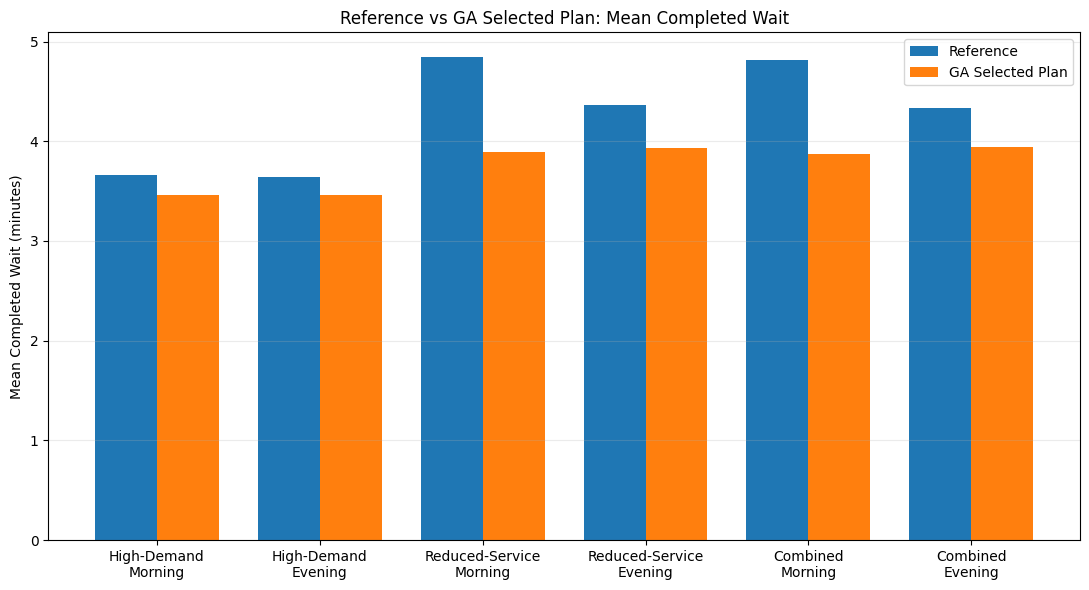

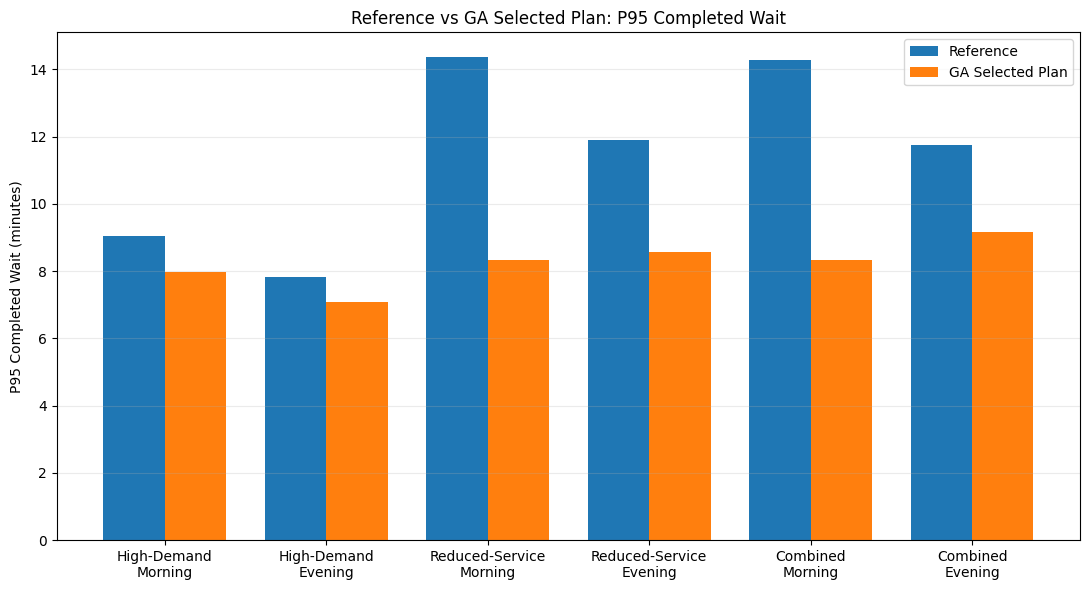

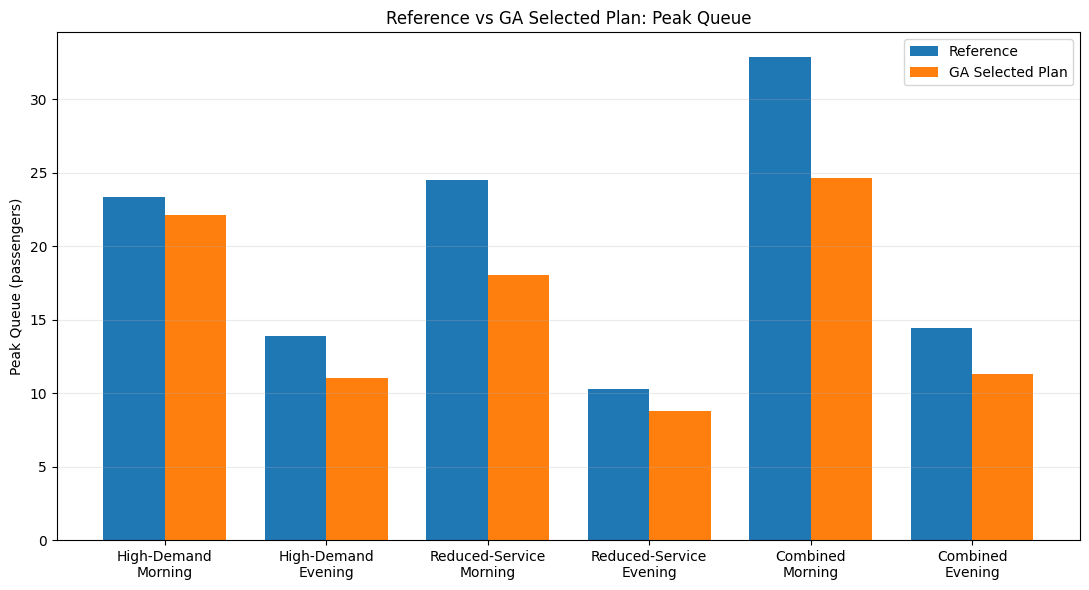

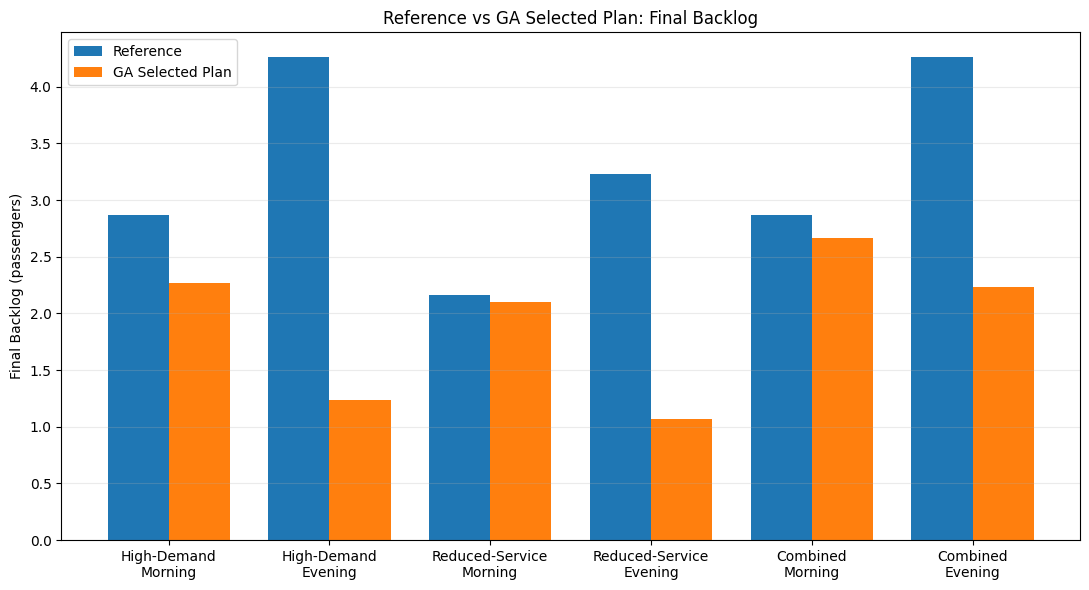

GA comparison figures created successfully:
- ga_reference_vs_optimized_mean_wait.png
- ga_reference_vs_optimized_p95_wait.png
- ga_reference_vs_optimized_peak_queue.png
- ga_reference_vs_optimized_final_backlog.png
GA output manifest updated with reviewer-facing figures: True


In [57]:
#generate reviewer-facing reference-versus-ga figures from the final
#paired comparison table. this cell does not rerun or alter the ga search.

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

working_dir = Path.cwd()
project_candidates = [
    working_dir,
    working_dir.parent,
    working_dir / "MODESIM_Project",
]

figure_project_dir = next(
    (
        path
        for path in project_candidates
        if (path / "code").exists() and (path / "output").exists()
    ),
    None,
)

if figure_project_dir is None:
    raise FileNotFoundError(
        "Could not locate MODESIM_Project for GA figure generation."
    )

figure_tables_dir = figure_project_dir / "output" / "tables"
figure_output_dir = figure_project_dir / "output" / "figures"
figure_output_dir.mkdir(parents=True, exist_ok=True)

paired_results_file = (
    figure_tables_dir / "ga_scenario_paired_reference_vs_ga.csv"
)

if not paired_results_file.exists():
    raise FileNotFoundError(
        "Missing ga_scenario_paired_reference_vs_ga.csv. "
        "Run the GA result-export section first."
    )

paired_results = pd.read_csv(paired_results_file)

required_columns = {
    "Scenario",
    "Period",
    "Metric",
    "Mean GA",
    "Mean Reference",
}

missing_columns = required_columns.difference(paired_results.columns)
if missing_columns:
    raise ValueError(
        "Paired GA table is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

scenario_order = ["High-Demand", "Reduced-Service", "Combined"]
period_order = ["Morning", "Evening"]

figure_specs = [
    (
        "Mean Completed Wait",
        "Mean Completed Wait (minutes)",
        "ga_reference_vs_optimized_mean_wait.png",
    ),
    (
        "P95 Completed Wait",
        "P95 Completed Wait (minutes)",
        "ga_reference_vs_optimized_p95_wait.png",
    ),
    (
        "Peak Queue",
        "Peak Queue (passengers)",
        "ga_reference_vs_optimized_peak_queue.png",
    ),
    (
        "Final Backlog",
        "Final Backlog (passengers)",
        "ga_reference_vs_optimized_final_backlog.png",
    ),
]

generated_ga_figures = []

order_lookup = {
    (scenario, period): index
    for index, (scenario, period) in enumerate(
        (scenario, period)
        for scenario in scenario_order
        for period in period_order
    )
}

for metric, y_label, filename in figure_specs:
    metric_rows = paired_results[
        paired_results["Metric"].eq(metric)
    ].copy()

    metric_rows = metric_rows[
        metric_rows["Scenario"].isin(scenario_order)
        & metric_rows["Period"].isin(period_order)
    ].copy()

    if len(metric_rows) != 6:
        raise ValueError(
            f"Expected 6 stress-scenario rows for {metric}, "
            f"found {len(metric_rows)}."
        )

    metric_rows["Plot Order"] = metric_rows.apply(
        lambda row: order_lookup[(row["Scenario"], row["Period"])],
        axis=1,
    )
    metric_rows = metric_rows.sort_values("Plot Order").reset_index(drop=True)

    labels = [
        f"{scenario}\n{period}"
        for scenario, period in zip(
            metric_rows["Scenario"],
            metric_rows["Period"],
        )
    ]

    x_positions = list(range(len(metric_rows)))
    bar_width = 0.38

    fig, ax = plt.subplots(figsize=(11, 6))

    reference_positions = [
        position - bar_width / 2 for position in x_positions
    ]
    ga_positions = [
        position + bar_width / 2 for position in x_positions
    ]

    ax.bar(
        reference_positions,
        metric_rows["Mean Reference"],
        width=bar_width,
        label="Reference",
    )
    ax.bar(
        ga_positions,
        metric_rows["Mean GA"],
        width=bar_width,
        label="GA Selected Plan",
    )

    ax.set_title(f"Reference vs GA Selected Plan: {metric}")
    ax.set_ylabel(y_label)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()

    output_path = figure_output_dir / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    #show this plot in the notebook before closing its figure
    plt.show()
    plt.close(fig)

    generated_ga_figures.append(output_path)

manifest_path = figure_tables_dir / "ga_output_manifest.csv"

if not manifest_path.exists():
    raise FileNotFoundError(
        "Missing ga_output_manifest.csv. Run the GA export section first."
    )

ga_manifest = pd.read_csv(manifest_path)

expected_manifest_columns = {"File", "Directory", "Purpose"}
if not expected_manifest_columns.issubset(ga_manifest.columns):
    raise ValueError(
        "ga_output_manifest.csv has an unexpected column structure."
    )

figure_manifest_rows = pd.DataFrame(
    [
        {
            "File": path.name,
            "Directory": "output/figures",
            "Purpose": "Reviewer-facing reference-versus-GA comparison figure",
        }
        for path in generated_ga_figures
    ]
)

ga_manifest = pd.concat(
    [ga_manifest, figure_manifest_rows],
    ignore_index=True,
).drop_duplicates(
    subset=["File", "Directory"],
    keep="last",
)

ga_manifest.to_csv(manifest_path, index=False)

missing_figures = [
    str(path)
    for path in generated_ga_figures
    if not path.exists() or path.stat().st_size == 0
]

if missing_figures:
    raise RuntimeError(
        "One or more GA comparison figures were not created:\n"
        + "\n".join(missing_figures)
    )

print("GA comparison figures created successfully:")
for path in generated_ga_figures:
    print(f"- {path.name}")

print("GA output manifest updated with reviewer-facing figures: True")

#make local modules work from the repository root or the notebook folder
import sys
code_dir = str(project_dir / "code")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)
from m66_support import (
    PASSENGER_COLUMNS, allocate_initial_occupancy, finite_replications,
    paired_difference, validate_demand
)


## Independent test and simple service controls
The selected plans are frozen before 30 unused passenger seeds are generated. These test results never change the plans. The regularized reference keeps the published hourly trip counts but uses the same midpoint spacing and median travel offsets as GA. The demand rule uses the same trip budget and bounds. Paired stop intervals are pointwise checks, so they do not prove every stop improves at once.


In [58]:
#run the frozen plans on new seeds and compare them with simple service rules
from m66_evaluation import run_review_evaluation
baseline_reference_service = {
    "stop_times": study_stop_times, "period_lookup": trip_period_lookup,
    "occupancy_lookup": initial_occupancy_lookup, "alighting_lookup": alighting_lookup
}
reduced_reference_service = {
    "stop_times": reduced_study_stop_times, "period_lookup": reduced_trip_period_lookup,
    "occupancy_lookup": reduced_initial_occupancy_lookup, "alighting_lookup": reduced_alighting_lookup
}
review_holdout_comparisons = run_review_evaluation(
    scenario_contexts, selected_ga_plans, baseline_demand, additional_demand,
    {"Baseline": baseline_reference_service, "High-Demand": baseline_reference_service,
     "Reduced-Service": reduced_reference_service, "Combined": reduced_reference_service},
    evaluate_selected_plan_detailed, tables_dir, master_seed
)
review_holdout_comparisons


,Metric,Replications,Reference Mean,Candidate Mean,Paired Difference,Difference CI Lower,Difference CI Upper,Reduction Supported,Scenario,Period,Comparison
0,Mean Completed Wait,30,3.645564,3.498769,-0.146796,-0.199593,-0.093998,True,Baseline,Morning,GA minus Published Reference
1,P95 Completed Wait,30,9.062969,7.307147,-1.755822,-1.877532,-1.634112,True,Baseline,Morning,GA minus Published Reference
2,Peak Queue,30,17.800000,17.433333,-0.366667,-1.465142,0.731809,False,Baseline,Morning,GA minus Published Reference
3,Final Backlog,30,1.633333,1.200000,-0.433333,-0.686843,-0.179824,True,Baseline,Morning,GA minus Published Reference
4,Mean Completed Wait,30,3.645564,3.611344,-0.034220,-0.083247,0.014807,False,Baseline,Morning,Regularized Reference minus Published Reference
...,...,...,...,...,...,...,...,...,...,...,...
155,Final Backlog,30,2.400000,2.400000,0.000000,0.000000,0.000000,False,Combined,Evening,GA minus Regularized Reference
156,Mean Completed Wait,30,3.941660,3.994273,0.052613,0.004598,0.100629,False,Combined,Evening,GA minus Demand Rule
157,P95 Completed Wait,30,9.179480,9.069944,-0.109536,-0.204193,-0.014879,True,Combined,Evening,GA minus Demand Rule
158,Peak Queue,30,11.833333,11.833333,0.000000,-0.098061,0.098061,False,Combined,Evening,GA minus Demand Rule


## Independent-test figures

The paired intervals and stop comparisons use the frozen plans and unused seeds. The queue plot shows one reference replication; it is an illustration rather than an average across replications.


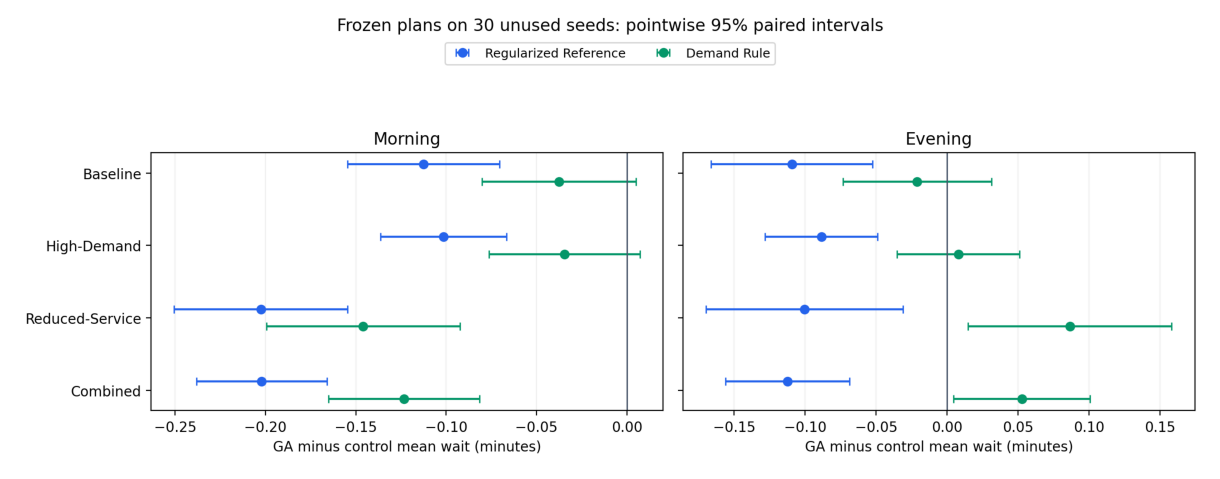

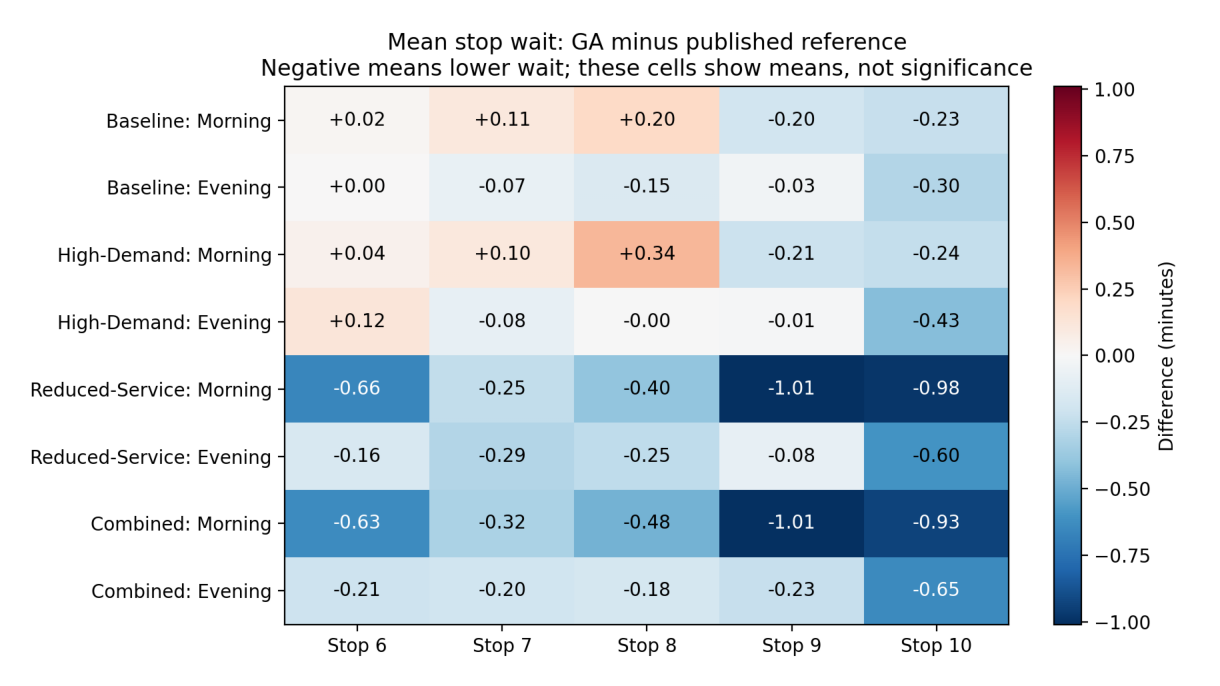

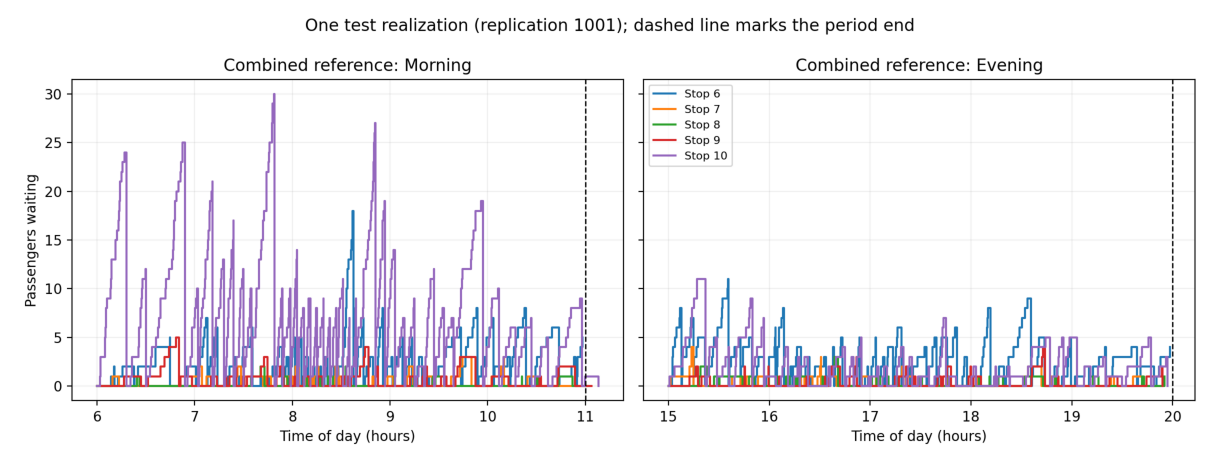

In [59]:
#make the independent-test plots from the saved comparison tables
from pathlib import Path
import subprocess
import sys
import matplotlib.pyplot as plt

#find the project from the notebook folder or the repository root
working_dir = Path.cwd()
project_candidates = [working_dir, working_dir.parent, working_dir / "MODESIM_Project"]
figure_project_dir = next(
    (path for path in project_candidates
     if (path / "code" / "plot_results.py").is_file()
     and (path / "output" / "tables").is_dir()),
    None,
)
if figure_project_dir is None:
    raise FileNotFoundError("Could not locate MODESIM_Project for independent-test plots.")

#this redraws the figures without searching again or changing the frozen plans
subprocess.run(
    [sys.executable, str(figure_project_dir / "code" / "plot_results.py")],
    check=True,
)

#display each image so it is included when this notebook is exported
figure_names = [
    "review_holdout_wait_differences.png",
    "review_holdout_stop_wait_tradeoffs.png",
    "review_reference_queue_combined.png",
]
for filename in figure_names:
    image_path = figure_project_dir / "output" / "figures" / filename
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing independent-test figure: {image_path}")
    image = plt.imread(image_path)
    #keep the image proportions so the labels stay readable
    height, width = image.shape[:2]
    fig, ax = plt.subplots(figsize=(12, 12 * height / width))
    ax.imshow(image)
    ax.axis("off")
    fig.tight_layout(pad=0)
    plt.show()
    plt.close(fig)
